# NLP Pipeline — Phase 1
### OCR → tokens → stopwords → lemmas → named entities → key phrases
---

## Imports

In [1]:
!pip install --upgrade certifi


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())



In [3]:
# ── Image / OCR ───────────────────────────────────────────────────────────
import cv2
import pytesseract

# ── Core NLP ──────────────────────────────────────────────────────────────
import spacy
from spacy import displacy
from IPython.display import display, HTML

# ── NLTK ──────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords',  quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('wordnet',    quiet=True)

# ── Utilities ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Load spaCy model
nlp = spacy.load('en_core_web_sm')



[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


---
## 0. Source Document — PDF, image, or text file. One variable controls what the whole pipeline reads.

Set `SOURCE_FILE` below to any supported format:

| Extension | What happens |
|-----------|-------------|
| `.pdf`    | Chosen page rendered to PNG at 200 DPI via pypdfium2 / PyMuPDF |
| `.jpg` `.jpeg` `.png` `.bmp` `.tiff` | Used directly as the input image |
| `.txt`    | Text read straight from disk — OCR step is skipped entirely |

All paths through the pipeline converge on `ocr_text` by the end of this
section, so every downstream cell (tokenisation, BoW, TF-IDF, LLM, etc.)
works unchanged regardless of the source format.

Phase 2 image steps require an image source. If `SOURCE_FILE` is a `.txt`
file, Section 2.0a and the image feature pipeline are skipped automatically.


In [4]:
# -- Universal source loader -----------------------------------------------
# Set SOURCE_FILE to any supported file. PAGE_NUM and DPI are only used
# when the source is a PDF.
#
# Supported:
#   .pdf             -> page rendered to PNG via pypdfium2 (fallback: PyMuPDF)
#   .jpg .jpeg .png .bmp .tiff .tif  -> image used directly, no conversion
#   .txt             -> text read from disk, OCR is skipped
#
# References:
#   pypdfium2  -- https://pypdfium2.readthedocs.io/en/stable/
#   PyMuPDF    -- https://pymupdf.readthedocs.io/en/latest/

import os, sys, subprocess

#SOURCE_FILE  = 'Eventos-deportivos-EN.pdf'   # <-- change to your file (.pdf / .jpg / .png / .txt)
SOURCE_FILE = 'ploughing.jpg'
PAGE_NUM     = 0             # 0-based page number (PDF only, ignored otherwise)
DPI          = 200

# Internal state set below — used by downstream cells
RENDERED_PNG  = None   # path to the image that Phase 1 OCR and Phase 2 will use
_direct_text  = None   # populated for .txt sources; OCR cell checks this
PDF_FILE      = None   # kept for Section 2.0a backwards-compat (PDF only)

_ext = os.path.splitext(SOURCE_FILE)[1].lower()
_IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

if not os.path.exists(SOURCE_FILE):
    raise FileNotFoundError(
        f"Could not find '{SOURCE_FILE}'. "
        "Make sure the file is in the same directory as this notebook."
    )

if _ext == '.pdf':
    PDF_FILE     = SOURCE_FILE
    RENDERED_PNG = 'paper_p1.png'
    _render_lib  = None
    try:
        import pypdfium2 as _pdfium
        _render_lib = 'pypdfium2'
    except ImportError:
        try:
            import fitz as _fitz
            _render_lib = 'fitz'
        except ImportError:
            print('No PDF library found; installing pypdfium2...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'pypdfium2'])
            import pypdfium2 as _pdfium
            _render_lib = 'pypdfium2'

    if _render_lib == 'pypdfium2':
        _pdf = _pdfium.PdfDocument(PDF_FILE)
        _img_pil = _pdf[PAGE_NUM].render(scale=DPI / 72).to_pil()
        _img_pil.save(RENDERED_PNG)
        _w, _h = _img_pil.width, _img_pil.height
        _pdf.close()
    else:
        _doc = _fitz.open(PDF_FILE)
        _pix = _doc[PAGE_NUM].get_pixmap(
            matrix=_fitz.Matrix(DPI / 72, DPI / 72), alpha=False
        )
        _pix.save(RENDERED_PNG)
        _w, _h = _pix.width, _pix.height
        _doc.close()

    print(f'PDF  : rendered page {PAGE_NUM + 1} of "{SOURCE_FILE}"  ({_render_lib})')
    print(f'    -> {RENDERED_PNG}  ({_w} x {_h} px @ {DPI} DPI)')

elif _ext in _IMAGE_EXTS:
    RENDERED_PNG = SOURCE_FILE
    print(f'Image: "{SOURCE_FILE}" will be used directly as input.')

elif _ext == '.txt':
    with open(SOURCE_FILE, 'r', encoding='utf-8', errors='replace') as _f:
        _direct_text = _f.read()
    print(f'Text : "{SOURCE_FILE}" loaded ({len(_direct_text):,} chars) — OCR will be skipped.')

else:
    raise ValueError(
        f"Unsupported file type '{_ext}'. "
        "Supported formats: .pdf  .jpg  .jpeg  .png  .bmp  .tiff  .tif  .txt"
    )


Image: "ploughing.jpg" will be used directly as input.


---
## Image Input & OCR — Tesseract reads pixel data and converts it to a raw text string. 

Image loaded: ploughing.jpg
Shape (height, width, channels): (1536, 2048, 3)


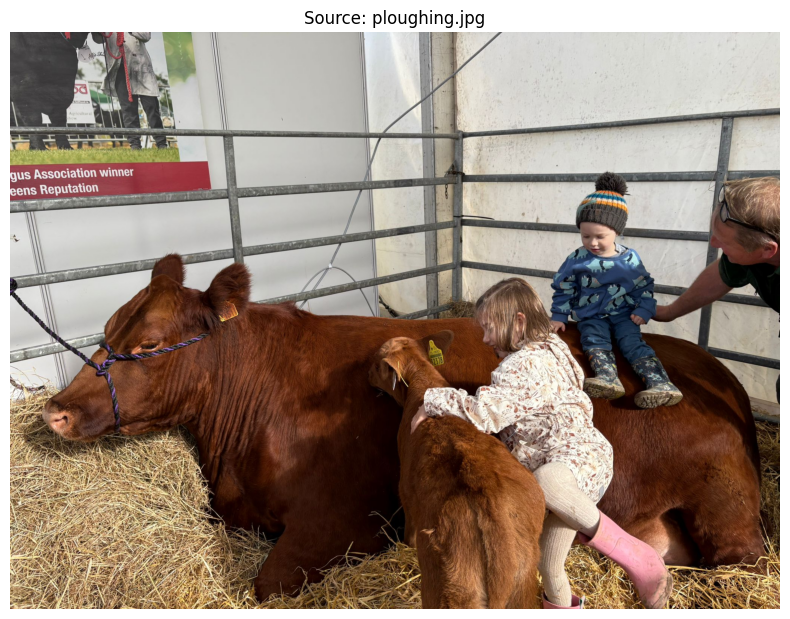

In [5]:
# -- Load and display source image -----------------------------------------
# Skipped for .txt sources — ocr_text is set directly in the next cell.
# cv2.imread / cv2.cvtColor pattern: WK6 Lab Code.

if _direct_text is not None:
    # Text file: nothing to display as an image
    img     = None
    img_rgb = None
    IMAGE_FILE = SOURCE_FILE
    print(f'Source is a text file — no image to display.')
    print(f'\nPreview (first 500 chars):')
    print('-' * 60)
    print(_direct_text[:500])
else:
    IMAGE_FILE = RENDERED_PNG
    img = cv2.imread(IMAGE_FILE)

    if img is None:
        raise FileNotFoundError(
            f"Could not load '{IMAGE_FILE}'. "
            "Make sure the file is in the same directory as this notebook."
        )

    print(f'Image loaded: {IMAGE_FILE}')
    print(f'Shape (height, width, channels): {img.shape}')

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Source: {IMAGE_FILE}', fontsize=12)
    plt.tight_layout()
    plt.show()


In [6]:
# -- OCR with Tesseract ----------------------------------------------------
# Skipped for .txt sources — text is already in _direct_text.
# --oem 1  = LSTM neural network engine (Tesseract 5)
# --psm 6  = assume a uniform block of text

if _direct_text is not None:
    ocr_text = _direct_text
    print(f'Text file: using file content directly as ocr_text ({len(ocr_text):,} chars, no OCR needed).')
else:
    custom_config = r'--oem 1 --psm 6'
    ocr_text = pytesseract.image_to_string(img, config=custom_config)
    print('=== RAW OCR OUTPUT ===')
    print(ocr_text)


=== RAW OCR OUTPUT ===
N mf A |
iN A » 2 i ioe |
me aes | We |
? AY yall
gus Association winner a yi B
eens Reputation PO) 7 a _ I i.
we pina PIT OS te ton —_ 4 (} AYE, S
. <pee L - i li ve Ss
“ ms — am AN ey —
Ma ast ww Mie NNN = ee
ws: Y Pri eg a ey e N
GPE S\N SAO ES iS a here, ree
eo 12 a4 . YF
GA SE IR. 4 ak :
fo
SIO, I 4
OE Ge aes! pr aN
Peele Laeger ee) { ‘ '
LD RO a Lae . & Qs \
oe rea, Ye SN



---
## 1. Tokenisation — splits raw text into individual word tokens. First step in making text machine-readable.
### 1a. NLTK Tokenisation — rule-based word splitting using the punkt tokeniser.

In [7]:
# ── Tokenise the OCR text using NLTK word_tokenize ────────────────────────
text_tokens = word_tokenize(ocr_text)

print('=== NLTK TOKENS ===')
print(text_tokens)
print(f'\nTotal tokens: {len(text_tokens)}')

=== NLTK TOKENS ===
['N', 'mf', 'A', '|', 'iN', 'A', '»', '2', 'i', 'ioe', '|', 'me', 'aes', '|', 'We', '|', '?', 'AY', 'yall', 'gus', 'Association', 'winner', 'a', 'yi', 'B', 'eens', 'Reputation', 'PO', ')', '7', 'a', '_', 'I', 'i.', 'we', 'pina', 'PIT', 'OS', 'te', 'ton', '—', '_', '4', '(', '}', 'AYE', ',', 'S', '.', '<', 'pee', 'L', '-', 'i', 'li', 've', 'Ss', '“', 'ms', '—', 'am', 'AN', 'ey', '—', 'Ma', 'ast', 'ww', 'Mie', 'NNN', '=', 'ee', 'ws', ':', 'Y', 'Pri', 'eg', 'a', 'ey', 'e', 'N', 'GPE', 'S\\N', 'SAO', 'ES', 'iS', 'a', 'here', ',', 'ree', 'eo', '12', 'a4', '.', 'YF', 'GA', 'SE', 'IR', '.', '4', 'ak', ':', 'fo', 'SIO', ',', 'I', '4', 'OE', 'Ge', 'aes', '!', 'pr', 'aN', 'Peele', 'Laeger', 'ee', ')', '{', '‘', "'", 'LD', 'RO', 'a', 'Lae', '.', '&', 'Qs', '\\', 'oe', 'rea', ',', 'Ye', 'SN']

Total tokens: 132


### 1b. spaCy Tokenisation — linguistically-aware splitting that handles contractions, punctuation, and special characters.

In [8]:
# ── Tokenise with spaCy ───────────────────────────────────────────────────
doc = nlp(ocr_text)

print('=== spaCy TOKENS ===')
for token in doc:
    print(token.text, token.pos_, end=' | ')

print(f'\n\nTotal tokens: {len(doc)}')
print(f'Vocabulary size (en_core_web_sm): {len(doc.vocab)}')

=== spaCy TOKENS ===
N CCONJ | mf INTJ | A DET | | NOUN | 
 SPACE | iN ADP | A DET | » NOUN | 2 NUM | i PRON | ioe PROPN | | PROPN | 
 SPACE | me PRON | aes VERB | | NOUN | We PRON | | ADV | 
 SPACE | ? PUNCT | AY PROPN | y PRON | all DET | 
 SPACE | gus PROPN | Association PROPN | winner NOUN | a DET | yi PROPN | B PROPN | 
 SPACE | eens VERB | Reputation PROPN | PO PROPN | ) PUNCT | 7 NUM | a DET | _ NOUN | I PRON | i. VERB | 
 SPACE | we PRON | pina VERB | PIT PROPN | OS NOUN | te ADP | ton NOUN | — PUNCT | _ NOUN | 4 NUM | ( PUNCT | } PUNCT | AYE PROPN | , PUNCT | S PROPN | 
 SPACE | . PUNCT | < X | pee PROPN | L PROPN | - PUNCT | i PRON | li PROPN | ve AUX | Ss PROPN | 
 SPACE | “ PUNCT | ms PROPN | — PUNCT | am AUX | AN DET | ey PRON | — PUNCT | 
 SPACE | Ma PROPN | ast X | ww PROPN | Mie PROPN | NNN PROPN | = PROPN | ee PROPN | 
 SPACE | ws NOUN | : PUNCT | Y PROPN | Pri PROPN | eg VERB | a DET | ey PRON | e PROPN | N PROPN | 
 SPACE | GPE PROPN | S\N NOUN | SAO PROPN | ES PROPN

---
## 2. Stopword Removal — filters out high-frequency words like "the" and "and" that carry no meaning.
### 2a. NLTK Stopword List — removes common English words from the token stream.

In [9]:
# ── NLTK stopword removal on OCR text ────────────────────────────────────
nltk_stopwords = stopwords.words('english')

tokens_without_sw = [word for word in text_tokens if word not in nltk_stopwords]

print('=== AFTER NLTK STOPWORD REMOVAL ===')
print(tokens_without_sw)
print(f'\nOriginal token count : {len(text_tokens)}')
print(f'After filtering      : {len(tokens_without_sw)}')
print(f'Stopwords removed    : {len(text_tokens) - len(tokens_without_sw)}')
print(f'\nNLTK stopword list size: {len(nltk_stopwords)}')
print(nltk_stopwords)

=== AFTER NLTK STOPWORD REMOVAL ===
['N', 'mf', 'A', '|', 'iN', 'A', '»', '2', 'ioe', '|', 'aes', '|', 'We', '|', '?', 'AY', 'yall', 'gus', 'Association', 'winner', 'yi', 'B', 'eens', 'Reputation', 'PO', ')', '7', '_', 'I', 'i.', 'pina', 'PIT', 'OS', 'te', 'ton', '—', '_', '4', '(', '}', 'AYE', ',', 'S', '.', '<', 'pee', 'L', '-', 'li', 'Ss', '“', 'ms', '—', 'AN', 'ey', '—', 'Ma', 'ast', 'ww', 'Mie', 'NNN', '=', 'ee', 'ws', ':', 'Y', 'Pri', 'eg', 'ey', 'e', 'N', 'GPE', 'S\\N', 'SAO', 'ES', 'iS', ',', 'ree', 'eo', '12', 'a4', '.', 'YF', 'GA', 'SE', 'IR', '.', '4', 'ak', ':', 'fo', 'SIO', ',', 'I', '4', 'OE', 'Ge', 'aes', '!', 'pr', 'aN', 'Peele', 'Laeger', 'ee', ')', '{', '‘', "'", 'LD', 'RO', 'Lae', '.', '&', 'Qs', '\\', 'oe', 'rea', ',', 'Ye', 'SN']

Original token count : 132
After filtering      : 120
Stopwords removed    : 12

NLTK stopword list size: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at'

### 2b. Extending Stopwords — adding custom domain-specific words to the default list.

In [10]:
# ── Add a single custom stopword ──────────────────────────────────────────
all_stopwords = stopwords.words('english')
all_stopwords.append('Lorem')

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('After appending "Lorem":')
print(tokens_without_sw)
print(f'Stopword count: {len(all_stopwords)}')

# ── Extend with a list of custom stopwords ────────────────────────────────
sw_list = ['Ipsum', 'dummy', '2000', 'simply']
all_stopwords.extend(sw_list)

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('\nAfter extending with list:')
print(tokens_without_sw)
print(f'Stopword count: {len(all_stopwords)}')

After appending "Lorem":
['N', 'mf', 'A', '|', 'iN', 'A', '»', '2', 'ioe', '|', 'aes', '|', 'We', '|', '?', 'AY', 'yall', 'gus', 'Association', 'winner', 'yi', 'B', 'eens', 'Reputation', 'PO', ')', '7', '_', 'I', 'i.', 'pina', 'PIT', 'OS', 'te', 'ton', '—', '_', '4', '(', '}', 'AYE', ',', 'S', '.', '<', 'pee', 'L', '-', 'li', 'Ss', '“', 'ms', '—', 'AN', 'ey', '—', 'Ma', 'ast', 'ww', 'Mie', 'NNN', '=', 'ee', 'ws', ':', 'Y', 'Pri', 'eg', 'ey', 'e', 'N', 'GPE', 'S\\N', 'SAO', 'ES', 'iS', ',', 'ree', 'eo', '12', 'a4', '.', 'YF', 'GA', 'SE', 'IR', '.', '4', 'ak', ':', 'fo', 'SIO', ',', 'I', '4', 'OE', 'Ge', 'aes', '!', 'pr', 'aN', 'Peele', 'Laeger', 'ee', ')', '{', '‘', "'", 'LD', 'RO', 'Lae', '.', '&', 'Qs', '\\', 'oe', 'rea', ',', 'Ye', 'SN']
Stopword count: 199

After extending with list:
['N', 'mf', 'A', '|', 'iN', 'A', '»', '2', 'ioe', '|', 'aes', '|', 'We', '|', '?', 'AY', 'yall', 'gus', 'Association', 'winner', 'yi', 'B', 'eens', 'Reputation', 'PO', ')', '7', '_', 'I', 'i.', 'pina', 

### 2c. Removing a Stopword — keeping "not" so negation is preserved in the token stream.

In [11]:
# ── Remove 'not' so negation is preserved ────────────────────────────────
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('After removing "not" from stopwords:')
print(tokens_without_sw)

After removing "not" from stopwords:
['N', 'mf', 'A', '|', 'iN', 'A', '»', '2', 'ioe', '|', 'aes', '|', 'We', '|', '?', 'AY', 'yall', 'gus', 'Association', 'winner', 'yi', 'B', 'eens', 'Reputation', 'PO', ')', '7', '_', 'I', 'i.', 'pina', 'PIT', 'OS', 'te', 'ton', '—', '_', '4', '(', '}', 'AYE', ',', 'S', '.', '<', 'pee', 'L', '-', 'li', 'Ss', '“', 'ms', '—', 'AN', 'ey', '—', 'Ma', 'ast', 'ww', 'Mie', 'NNN', '=', 'ee', 'ws', ':', 'Y', 'Pri', 'eg', 'ey', 'e', 'N', 'GPE', 'S\\N', 'SAO', 'ES', 'iS', ',', 'ree', 'eo', '12', 'a4', '.', 'YF', 'GA', 'SE', 'IR', '.', '4', 'ak', ':', 'fo', 'SIO', ',', 'I', '4', 'OE', 'Ge', 'aes', '!', 'pr', 'aN', 'Peele', 'Laeger', 'ee', ')', '{', '‘', "'", 'LD', 'RO', 'Lae', '.', '&', 'Qs', '\\', 'oe', 'rea', ',', 'Ye', 'SN']


### 2e. spaCy Stopword Removal — applying the filter to the full OCR text using the spaCy vocabulary.

In [12]:
# ── Apply spaCy stopword removal to OCR text ──────────────────────────────
doc = nlp(ocr_text)

filtered_tokens = [
    token.text
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
]
clean_text = ' '.join(filtered_tokens)

print('=== CLEANED TEXT (spaCy — stopwords + punctuation removed) ===')
print(clean_text)

total_count    = len([t for t in doc if not t.is_punct and not t.is_space])
filtered_count = len(filtered_tokens)
stopword_count = total_count - filtered_count

print(f'\nTotal tokens (with stopwords) : {total_count}')
print(f'Tokens (without stopwords)    : {filtered_count}')
print(f'Stopwords removed             : {stopword_count}')

=== CLEANED TEXT (spaCy — stopwords + punctuation removed) ===
N mf | 2 ioe | aes | | AY y gus Association winner yi B eens Reputation PO 7 i. pina PIT OS te ton 4 AYE S < pee L li ve Ss ms ey Ma ast ww Mie NNN = ee ws Y Pri eg ey e N GPE S\N SAO ES ree eo 12 a4 YF GA SE IR 4 ak fo SIO 4 OE Ge aes pr Peele Laeger ee LD RO Lae Qs oe rea Ye SN

Total tokens (with stopwords) : 104
Tokens (without stopwords)    : 83
Stopwords removed             : 21


---
## 3. Lemmatisation — reduces words to their base form: "running" → "run", "studies" → "study".
### 3a. spaCy Lemmatisation — context-aware, using part-of-speech to distinguish "meeting" the noun from "meeting" the verb.

In [13]:
# ── Lemmatise using spaCy ─────────────────────────────────────────────────
doc = nlp(ocr_text)

lemmatised = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
]

print('=== LEMMATISED TOKENS ===')
print(' | '.join(lemmatised))

=== LEMMATISED TOKENS ===
n | mf | | | 2 | ioe | | | aes | | | | | ay | you | gus | association | winner | yi | b | een | reputation | po | 7 | i. | pina | pit | os | te | ton | 4 | aye | s | < | pee | l | li | ve | ss | ms | ey | ma | ast | ww | mie | nnn | = | ee | ws | y | pri | eg | ey | e | n | gpe | s\n | sao | es | ree | eo | 12 | a4 | yf | ga | se | ir | 4 | ak | fo | sio | 4 | oe | ge | aes | pr | peele | laeger | ee | ld | ro | lae | qs | oe | rea | ye | sn


---
## 4. Named Entity Recognition (NER) — identifies people, organisations, places, and dates in the text.
### 4a. Entity Extraction — spaCy labels text spans with their type: PERSON, ORG, GPE, DATE.

In [14]:
# ── NER on the OCR text from the pipeline ────────────────────────────────
doc_object = nlp(ocr_text)

# Basic entity print
print('=== ENTITIES ===')
for entity in doc_object.ents:
    print(entity)

print()

# Entity + label
print('=== ENTITY + LABEL ===')
for entity in doc_object.ents:
    print(entity, entity.label_)

print()

# Entity + label + description
print('=== ENTITY + LABEL + DESCRIPTION ===')
for entity in doc_object.ents:
    print(entity, entity.label_, spacy.explain(entity.label_))



=== ENTITIES ===
2
aes
Association
Reputation PO
7
PIT
4
AYE
li
Ma
N
GPE
SAO ES
12
SE IR
4
4
Peele Laeger
LD RO a Lae .
Ye SN

=== ENTITY + LABEL ===
2 CARDINAL
aes PERSON
Association ORG
Reputation PO LOC
7 CARDINAL
PIT ORG
4 CARDINAL
AYE ORG
li PERSON
Ma PERSON
N GPE
GPE ORG
SAO ES ORG
12 CARDINAL
SE IR PERSON
4 CARDINAL
4 CARDINAL
Peele Laeger PERSON
LD RO a Lae . WORK_OF_ART
Ye SN PERSON

=== ENTITY + LABEL + DESCRIPTION ===
2 CARDINAL Numerals that do not fall under another type
aes PERSON People, including fictional
Association ORG Companies, agencies, institutions, etc.
Reputation PO LOC Non-GPE locations, mountain ranges, bodies of water
7 CARDINAL Numerals that do not fall under another type
PIT ORG Companies, agencies, institutions, etc.
4 CARDINAL Numerals that do not fall under another type
AYE ORG Companies, agencies, institutions, etc.
li PERSON People, including fictional
Ma PERSON People, including fictional
N GPE Countries, cities, states
GPE ORG Companies, agencies, i

In [15]:
# ── show_entity_info helper function ─────────────────────────────────────
def show_entity_info(doc_object):
    """Print entity text, label and description in a table."""
    if doc_object.ents:
        header = f'{"Entity":<30} {"Label":<20} {"Description"}'
        print(header)
        print('-' * 70)
        for entity in doc_object.ents:
            print(f'{entity.text:<30} {entity.label_:<20} {spacy.explain(entity.label_)}')
    else:
        print('No entities found in text.')

# ── Apply to the OCR text ─────────────────────────────────────────────────
print('=== NER — OCR TEXT ===')
show_entity_info(nlp(ocr_text))

=== NER — OCR TEXT ===
Entity                         Label                Description
----------------------------------------------------------------------
2                              CARDINAL             Numerals that do not fall under another type
aes                            PERSON               People, including fictional
Association                    ORG                  Companies, agencies, institutions, etc.
Reputation PO                  LOC                  Non-GPE locations, mountain ranges, bodies of water
7                              CARDINAL             Numerals that do not fall under another type
PIT                            ORG                  Companies, agencies, institutions, etc.
4                              CARDINAL             Numerals that do not fall under another type
AYE                            ORG                  Companies, agencies, institutions, etc.
li                             PERSON               People, including fictional
Ma         

### 4b. displaCy Visualisation — renders entity labels as colour-coded HTML spans inline in the notebook.

In [16]:
# ── Render NER with displaCy ──────────────────────────────────────────────
doc_object = nlp(ocr_text)

html = displacy.render(doc_object, style='ent', jupyter=False)
display(HTML(html))

---
## 5. Key Phrases — noun chunks extracted as the most informative multi-word phrases in the text.


In [17]:
# ── Key phrases from the OCR document ────────────────────────────────────
doc_ocr = nlp(ocr_text)

print(f'{"Phrase":<35} {"Root":<18} {"Dependency":<28} {"Head"}')
print('-' * 90)

for chunk in doc_ocr.noun_chunks:
    print(f'{chunk.text:<35} {chunk.root.text:<18} '
          f'{str(spacy.explain(chunk.root.dep_)):<28} {chunk.root.head.text}')

Phrase                              Root               Dependency                   Head
------------------------------------------------------------------------------------------
A »                                 »                  object of preposition        iN
i                                   i                  nominal subject              aes
ioe                                 ioe                appositional modifier        i
|
me                                me                 appositional modifier        i
AY y                                y                  nominal subject              winner
a yi B                              B                  appositional modifier        winner
Reputation PO                       PO                 direct object                eens
7 a _                               _                  root                         _
I                                   I                  nominal subject              i.
we                           

---
## 6. Bag-of-Words — counts how often each word appears. Turns text into a numeric matrix for machine learning.

A **Bag-of-Words (BoW)** representation converts text into a fixed-vocabulary count matrix:
each row is a *document* (here, one sentence from the OCR output) and each column is a
vocabulary term. Values are raw term counts. This is the simplest text feature representation
and underpins many downstream models (Naive Bayes, logistic regression, clustering).

We use `sklearn.feature_extraction.text.CountVectorizer` and treat each sentence of the
OCR text as a separate "document" so that we can demonstrate term-document statistics on a
single source image.


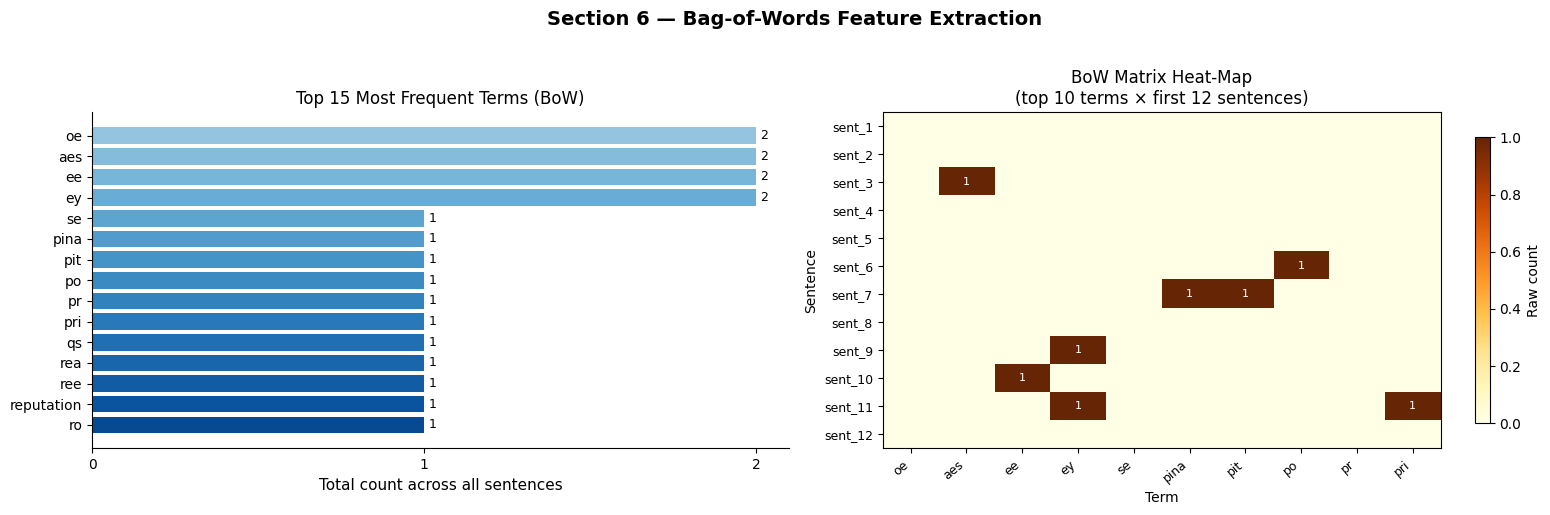

In [18]:
# ── Bag-of-Words on OCR text (computation + visualisation) ──────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Split the OCR output into sentence-level "documents"
sentences = [s.strip() for s in re.split(r'[.!?\n]+', ocr_text) if len(s.strip()) > 4]

bow_vectoriser = CountVectorizer(stop_words='english', lowercase=True, min_df=1)
bow_matrix     = bow_vectoriser.fit_transform(sentences)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectoriser.get_feature_names_out(),
    index=[f'sent_{i+1}' for i in range(len(sentences))]
)

totals = bow_df.sum(axis=0).sort_values(ascending=False)

TOP_N      = 15
top_terms  = totals.head(TOP_N)
top_labels = top_terms.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Section 6 — Bag-of-Words Feature Extraction', fontsize=14, fontweight='bold', y=1.02)

# ── Left: horizontal bar chart of top-N terms ────────────────────────
ax = axes[0]
colours = plt.cm.Blues(np.linspace(0.4, 0.9, TOP_N))[::-1]
bars = ax.barh(top_labels[::-1], top_terms.values[::-1], color=colours)
ax.set_xlabel('Total count across all sentences', fontsize=11)
ax.set_title(f'Top {TOP_N} Most Frequent Terms (BoW)', fontsize=12)
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Right: heat-map of the BoW matrix (top 10 terms x first 12 sentences) ──
ax2 = axes[1]
preview_cols = top_labels[:10]
hm_data = bow_df[preview_cols].head(12)
im = ax2.imshow(hm_data.values, aspect='auto', cmap='YlOrBr', interpolation='nearest')
ax2.set_xticks(range(len(preview_cols)))
ax2.set_xticklabels(preview_cols, rotation=40, ha='right', fontsize=9)
ax2.set_yticks(range(len(hm_data)))
ax2.set_yticklabels(hm_data.index, fontsize=9)
ax2.set_title('BoW Matrix Heat-Map\n(top 10 terms × first 12 sentences)', fontsize=12)
ax2.set_xlabel('Term', fontsize=10)
ax2.set_ylabel('Sentence', fontsize=10)
plt.colorbar(im, ax=ax2, label='Raw count', shrink=0.85)
for r in range(hm_data.shape[0]):
    for c in range(hm_data.shape[1]):
        v = hm_data.values[r, c]
        if v > 0:
            ax2.text(c, r, str(int(v)), ha='center', va='center', fontsize=8,
                     color='white' if v > hm_data.values.max() * 0.6 else 'black')

plt.tight_layout()
plt.show()


---
## 7. TF-IDF — down-weights common words, up-weights rare informative ones. Better than raw counts for distinguishing documents.

**TF-IDF (Term Frequency – Inverse Document Frequency)** down-weights terms that appear in
many documents (e.g. *the*, *and*) and up-weights terms that are concentrated in a few
documents — these are usually the most informative for distinguishing one document from
another.

We use `TfidfVectorizer` with `sublinear_tf=True` (logarithmic term-frequency scaling, which
dampens the effect of repeated words within a sentence) and inspect:

- the highest-weighted terms across the whole document, and
- the single strongest term per sentence (a quick "topic" indicator for each line).


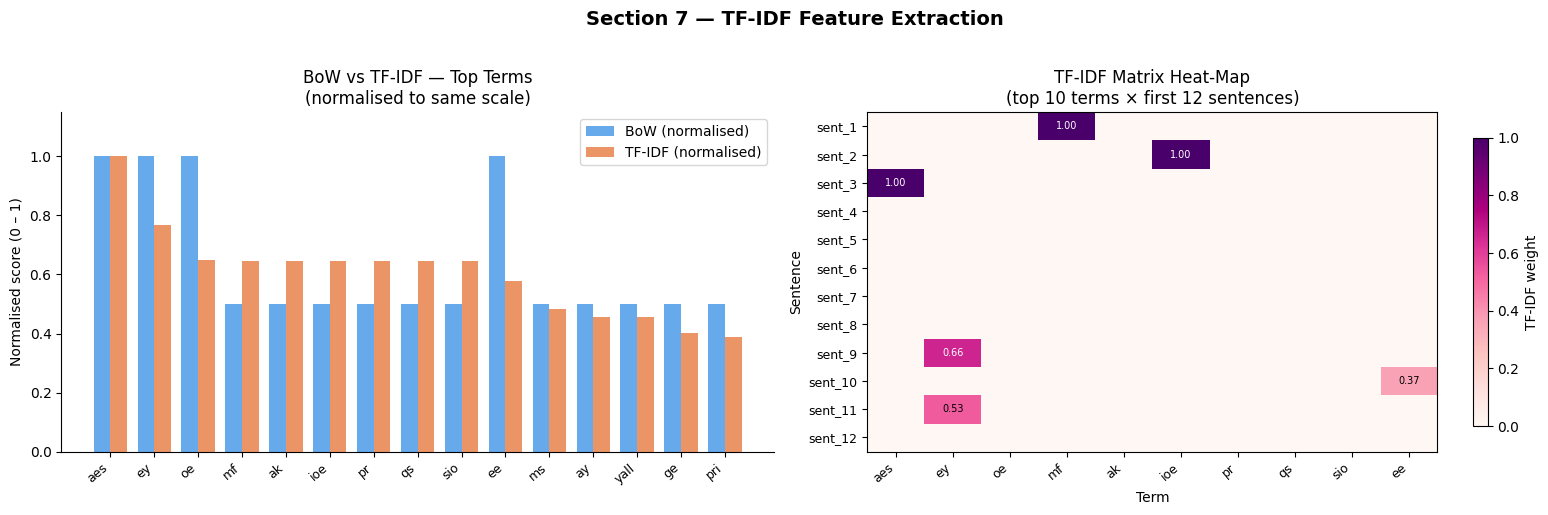

In [19]:
# ── TF-IDF on the same sentence-level corpus (computation + visualisation) ──
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt

tfidf_vectoriser = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    min_df=1,
    sublinear_tf=True
)
tfidf_matrix = tfidf_vectoriser.fit_transform(sentences)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectoriser.get_feature_names_out(),
    index=[f'sent_{i+1}' for i in range(len(sentences))]
)

weights = tfidf_df.sum(axis=0).sort_values(ascending=False)

TOP_N      = 15
top_tfidf  = weights.head(TOP_N)
shared     = [t for t in top_tfidf.index if t in totals.index]
bow_vals   = totals[shared].values
bow_norm   = bow_vals / (bow_vals.max() + 1e-9)
tfidf_vals = top_tfidf[shared].values
tfidf_norm = tfidf_vals / (tfidf_vals.max() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Section 7 — TF-IDF Feature Extraction', fontsize=14, fontweight='bold', y=1.02)

# ── Left: BoW vs TF-IDF grouped bar (normalised) ────────────────────
ax = axes[0]
x  = np.arange(len(shared))
w  = 0.38
b1 = ax.bar(x - w/2, bow_norm,   width=w, label='BoW (normalised)',    color='#4c9be8', alpha=0.85)
b2 = ax.bar(x + w/2, tfidf_norm, width=w, label='TF-IDF (normalised)', color='#e8834c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(shared, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Normalised score (0 – 1)', fontsize=10)
ax.set_title('BoW vs TF-IDF — Top Terms\n(normalised to same scale)', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 1.15)

# ── Right: TF-IDF heat-map across sentences ───────────────────────────
ax2 = axes[1]
hm_cols  = top_tfidf.index[:10].tolist()
hm_data2 = tfidf_df[hm_cols].head(12)
im2 = ax2.imshow(hm_data2.values, aspect='auto', cmap='RdPu', interpolation='nearest', vmin=0)
ax2.set_xticks(range(len(hm_cols)))
ax2.set_xticklabels(hm_cols, rotation=40, ha='right', fontsize=9)
ax2.set_yticks(range(len(hm_data2)))
ax2.set_yticklabels(hm_data2.index, fontsize=9)
ax2.set_title('TF-IDF Matrix Heat-Map\n(top 10 terms × first 12 sentences)', fontsize=12)
ax2.set_xlabel('Term', fontsize=10)
ax2.set_ylabel('Sentence', fontsize=10)
plt.colorbar(im2, ax=ax2, label='TF-IDF weight', shrink=0.85)
for r in range(hm_data2.shape[0]):
    for c in range(hm_data2.shape[1]):
        v = hm_data2.values[r, c]
        if v > 0.01:
            ax2.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=7,
                     color='white' if v > hm_data2.values.max() * 0.6 else 'black')

plt.tight_layout()
plt.show()


---
## 8. Section Categorisation — classifies each line as title, body text, or caption using rule-based heuristics.

The brief asks for *"categorising sections (e.g., separating titles, body text, and captions)"*.
With OCR output as a flat string, we apply lightweight rules to each non-empty line:

| Class       | Heuristic                                                           |
|-------------|----------------------------------------------------------------------|
| `caption`   | Line starts with *Figure / Fig. / Table / Caption* + optional number |
| `title`     | Short line (≤ 12 words) where ≥ 60% of words are capitalised, or ALL CAPS |
| `body`      | Everything else (default)                                            |

These are intentionally simple — a real system would combine font size, layout coordinates
from the OCR engine (`image_to_data`), and visual cues from Phase 2. They give us a structured
view of the document for downstream multi-modal integration in Phase 3.


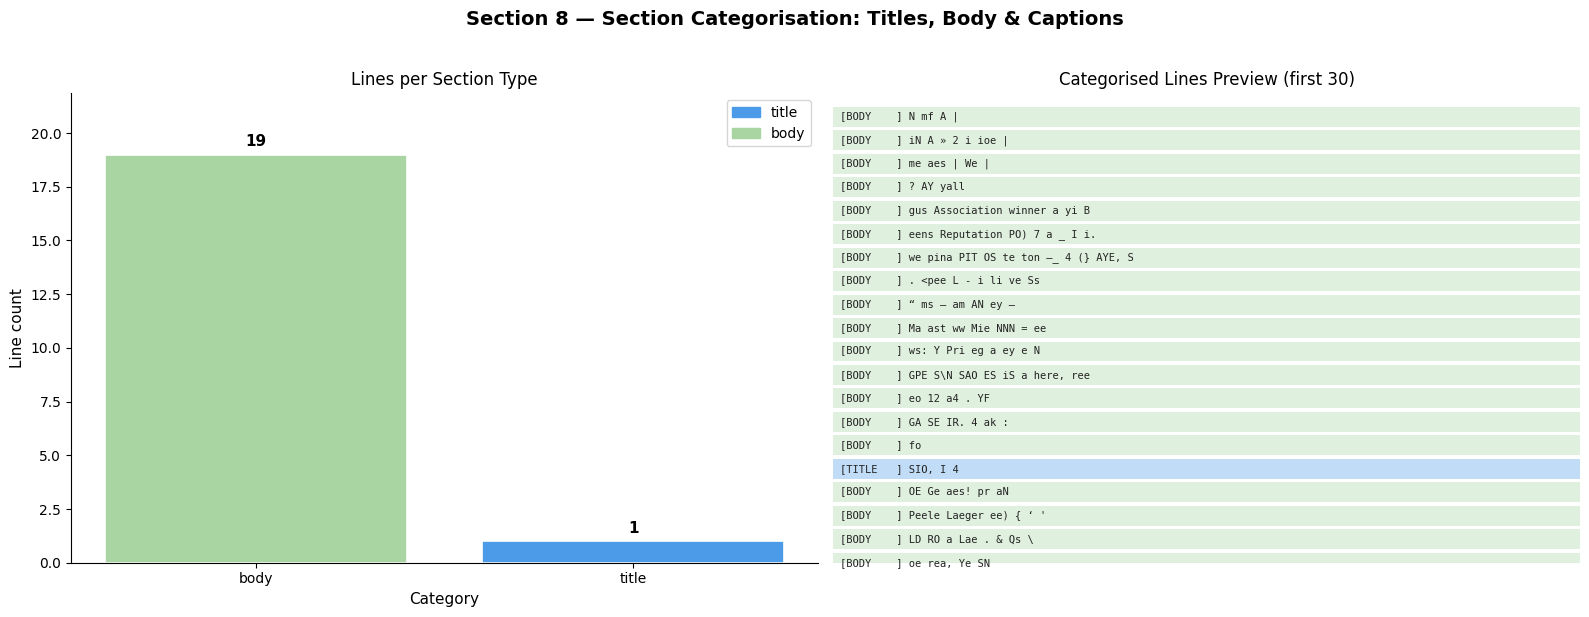

In [20]:
# ── Rule-based section categorisation with visual report ───────────────
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CAPTION_RE = re.compile(
    r'^(figure|fig\.?|table|tbl\.?|caption|chart|diagram)\s*\d*[:.)\]?]',
    re.IGNORECASE
)

def categorise_line(line: str) -> str:
    s = line.strip()
    if not s:
        return 'empty'
    if CAPTION_RE.match(s):
        return 'caption'
    words = s.split()
    if len(words) <= 12 and len(s) <= 80:
        cap_ratio = sum(1 for w in words if w[:1].isupper()) / max(len(words), 1)
        if s.isupper() or cap_ratio >= 0.6:
            return 'title'
    return 'body'

lines       = [l for l in ocr_text.split('\n') if l.strip()]
categorised = [(categorise_line(l), l.strip()) for l in lines]

# Build DataFrame (re-used in Phase 3)
sections_df = pd.DataFrame(categorised, columns=['section_type', 'text'])

# ── Colour palette per category ──────────────────────────────────────
CAT_COLOURS = {'title': '#4c9be8', 'body': '#a8d5a2', 'caption': '#f4a261', 'empty': '#e0e0e0'}
counts = sections_df['section_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section 8 — Section Categorisation: Titles, Body & Captions',
             fontsize=14, fontweight='bold', y=1.02)

# ── Left: bar chart of category distribution ─────────────────────────
ax = axes[0]
bar_colours = [CAT_COLOURS.get(c, '#cccccc') for c in counts.index]
bars = ax.bar(counts.index, counts.values, color=bar_colours, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, padding=4, fontsize=11, fontweight='bold')
ax.set_title('Lines per Section Type', fontsize=12)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Line count', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, counts.max() * 1.15)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLOURS.items() if k in counts.index]
ax.legend(handles=legend_patches, fontsize=10)

# ── Right: colour-coded line preview (first 30 non-empty lines) ───────────
ax2 = axes[1]
ax2.set_xlim(0, 1)
preview = [(c, t) for c, t in categorised if c != 'empty'][:30]
ax2.set_ylim(0, len(preview))
ax2.axis('off')
ax2.set_title('Categorised Lines Preview (first 30)', fontsize=12)
for row_i, (cat, text) in enumerate(reversed(preview)):
    colour = CAT_COLOURS.get(cat, '#dddddd')
    ax2.barh(row_i, 1, color=colour, alpha=0.35, height=0.85)
    label = f'[{cat.upper():<8}] {text[:62]}'
    ax2.text(0.01, row_i, label, va='center', fontsize=7.5,
             color='#222222', fontfamily='monospace')

plt.tight_layout()
plt.show()


---
## 9. Sentiment Analysis — VADER scores each sentence as positive, negative, or neutral without any training data.

The brief mentions sentiment analysis as one of the optional text-feature techniques.
We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a rule-based sentiment
analyser tuned for short, social-media-style text — ideal for noisy OCR output where
dependency-based models can struggle.

VADER returns four scores per text:

- `pos`, `neu`, `neg` — proportion of the text in each polarity bucket (sum to 1.0)
- `compound` — a single normalised score in [-1, +1] (the standard summary)

Conventional thresholds: **compound ≥ +0.05 → positive**, **≤ −0.05 → negative**, otherwise neutral.


In [21]:
# ── Sentiment analysis with VADER ────────────────────────────────
import nltk
# Had to manual download the vader_lexicon
#nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Whole-document sentiment
overall = sia.polarity_scores(ocr_text)
print('=== Overall document sentiment ===')
for k, v in overall.items():
    print(f'  {k:<10}: {v:+.3f}')

if   overall['compound'] >=  0.05: label = 'POSITIVE'
elif overall['compound'] <= -0.05: label = 'NEGATIVE'
else:                              label = 'NEUTRAL'
print(f'\n  -> Document classified as {label} (compound = {overall["compound"]:+.3f})')

# Per-sentence sentiment for the first 10 sentences
print('\n=== Per-sentence sentiment (first 10) ===')
for i, sent in enumerate(sentences[:10]):
    s = sia.polarity_scores(sent)
    snippet = sent[:65].replace('\n', ' ')
    print(f'  [compound={s["compound"]:+.2f}] {snippet}')


=== Overall document sentiment ===
  neg       : +0.000
  neu       : +0.948
  pos       : +0.052
  compound  : +0.624

  -> Document classified as POSITIVE (compound = +0.624)

=== Per-sentence sentiment (first 10) ===
  [compound=+0.00] N mf A |
  [compound=+0.00] iN A » 2 i ioe |
  [compound=+0.00] me aes | We |
  [compound=+0.00] AY yall
  [compound=+0.59] gus Association winner a yi B
  [compound=+0.00] eens Reputation PO) 7 a _ I i
  [compound=+0.00] we pina PIT OS te ton —_ 4 (} AYE, S
  [compound=+0.00] <pee L - i li ve Ss
  [compound=+0.00] “ ms — am AN ey —
  [compound=+0.00] Ma ast ww Mie NNN = ee


---
# Image Feature Engineering Pipeline
### Extract embedded figure → preprocess → detect features → binarise → label regions → draw bounding boxes
---

Phase 2 starts by **scanning the imported PDF for embedded raster images**.
The page selected by `PAGE_NUM` in Section 0 is parsed for every embedded
figure; the largest image (by pixel area) is extracted and Phase 2 runs the
full feature engineering pipeline on that figure rather than on the rendered
text page used in Phase 1. This is closer to a real-world workflow: locate the
figures inside an imported document, then characterise each one.

The extraction step uses **pypdfium2** (already imported in Section 0) to walk
the chosen page's page objects, filter for image objects, and pick the largest
by pixel area. The selected image is saved to disk as `doc_largest_image.png`
and re-used by every subsequent Phase 2 cell -- and by Phase 3's OCR + spatial
join -- so the whole image-side of the pipeline describes the same figure.


## 2.0  Image Pipeline Imports — OpenCV, NumPy, PIL, and pypdfium2 loaded for Phase 2.

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import pandas as pd

print(f'OpenCV version: {cv2.__version__}')
print('Scene feature engineering imports ready.')

OpenCV version: 4.13.0
Scene feature engineering imports ready.


---
## 2.0a  Embedded Image Extraction — scans PDF page objects and saves the largest raster figure to disk as doc_largest_image.png.

The PDF and the page are both set in **Section 0** (`PDF_FILE` and `PAGE_NUM`).
This section uses pypdfium2 to find every embedded raster image on that same
page and saves the largest one (by pixel area) to `doc_largest_image.png`. The
rest of Phase 2, plus Phase 3's spatial join, all run on that extracted image.

If the page does not contain any embedded raster image, the cell just prints
`no image found` -- check the PDF, set `PAGE_NUM` in Section 0 to a page that
has a figure, and re-run.

*Reference: pypdfium2 page-objects API --
https://pypdfium2.readthedocs.io/en/stable/python_api.html#module-pypdfium2*


In [23]:
# -- Section 2.0a: only runs when the source is a PDF ----------------------
if PDF_FILE is None:
    print(f'Source is not a PDF ("{SOURCE_FILE}") — embedded image extraction skipped.')
    # For image sources, use the input image itself as the extracted figure.
    # For text sources, Phase 2 image steps will have nothing to work with.
    EXTRACTED_IMAGE = RENDERED_PNG if RENDERED_PNG else None
else:
    # -- Locate the largest embedded image on the page chosen in Section 0 ----
    # PDF_FILE and PAGE_NUM are inherited from Section 0 -- the single place
    # where you pick the document and the page. Each PDF page object has a
    # `.type` field; raster images are type 3.
    import pypdfium2 as _pdfium
    from PIL import Image
    
    EXTRACTED_IMAGE = 'doc_largest_image.png'
    
    doc = _pdfium.PdfDocument(PDF_FILE)
    if PAGE_NUM >= len(doc):
        raise IndexError(
            f'PAGE_NUM={PAGE_NUM} but {PDF_FILE!r} only has {len(doc)} pages. '
            'Set PAGE_NUM in Section 0 to a valid page number.'
        )
    
    page = doc[PAGE_NUM]
    img_objs = [o for o in page.get_objects() if o.type == 3]
    print(f'Page {PAGE_NUM+1} of {PDF_FILE!r}: found {len(img_objs)} embedded raster image(s)')
    
    if not img_objs:
        print('no image found')
    else:
        # Render each image object to a PIL image, record dimensions, pick the largest.
        candidates = []
        for j, obj in enumerate(img_objs):
            bm = obj.get_bitmap(render=False)
            pil = bm.to_pil()
            candidates.append((pil.width * pil.height, j, pil))
            print(f'  image {j+1}: {pil.width} x {pil.height} px (mode={pil.mode})')
    
        candidates.sort(reverse=True)            # largest first
        _, chosen_idx, chosen_img = candidates[0]
        print(f'\nSelected image {chosen_idx+1} (largest, '
              f'{chosen_img.width} x {chosen_img.height} px).')
    
        # Save to disk so the WK6-lab cv2.imread pattern in Sec. 2.1 just works.
        chosen_img.save(EXTRACTED_IMAGE)
        print(f'Saved as: {EXTRACTED_IMAGE}')
    
        # Quick visual confirmation
        plt.figure(figsize=(10, 6))
        plt.imshow(chosen_img)
        plt.axis('off')
        plt.title(f'2.0a -- Largest embedded image extracted from page {PAGE_NUM+1}: '
                  f'{chosen_img.width} x {chosen_img.height} px')
        plt.tight_layout()
        plt.show()
    
    doc.close()


Source is not a PDF ("ploughing.jpg") — embedded image extraction skipped.


---
## 2.1  Preprocessing — grayscale conversion, Gaussian blur, Otsu binarisation. Converts the figure into a clean shape map.

Phase 2 operates on `doc_largest_image.png` -- the largest embedded image
extracted by Section 2.0a from the page set by `PAGE_NUM` in Section 0. The same WK6-lab
preparation steps are applied:

| Step | OpenCV call | Purpose |
|------|-------------|---------|
| RGB conversion | `cv2.cvtColor(..., COLOR_BGR2RGB)` | OpenCV reads BGR; Matplotlib expects RGB *(WK6 lab)* |
| Grayscale       | `cv2.cvtColor(..., COLOR_BGR2GRAY)` | Single-channel intensity for thresholding & edge detection *(WK6 lab)* |
| Gaussian blur   | `cv2.GaussianBlur(..., (5,5), 0)`   | Smooths noise / scan grain before binarisation *(WK6 lab)* |

The HSV channel is also computed; it is only used in the optional non-document
stress test in Section 2.8.


Phase 2 source: ploughing.jpg
Image size            : 2048 x 1536 pixels
Mean intensity (gray) : 125.8


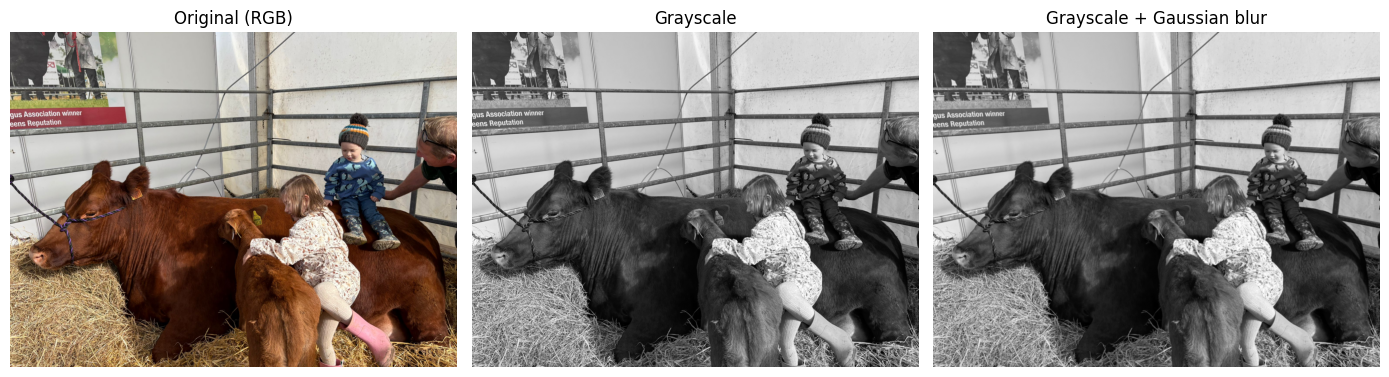

In [24]:
# -- Load image for Phase 2 layout analysis -----------------------------
# Primary source: doc_largest_image.png extracted by Section 2.0a.
# Fallback: RENDERED_PNG (full page) if no embedded image was found.
# Pattern from WK6 Lab Code: cv2.imread + cvtColor + GaussianBlur.

import os as _os
IMAGE_FILE = (
    EXTRACTED_IMAGE
    if (EXTRACTED_IMAGE and _os.path.exists(str(EXTRACTED_IMAGE)))
    else RENDERED_PNG
)
print("Phase 2 source:", IMAGE_FILE)

img_bgr = cv2.imread(IMAGE_FILE)
if img_bgr is None:
    raise FileNotFoundError(
        "Could not load '" + str(IMAGE_FILE) + "'. "
        "Check that Section 0 and 2.0a ran successfully."
    )

# -- Step 1 -- Colour-space conversions (WK6 lab) -----------------------
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # for Matplotlib display
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)   # used by stress test 2.8.2
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # for thresholding / edges

# -- Step 2 -- Noise reduction (WK6 lab) --------------------------------
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

H, W = img_gray.shape
print("Image size            :", W, "x", H, "pixels")
print("Mean intensity (gray) :", round(float(img_blur.mean()), 1))

# -- Display preprocessing stages ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes[0].imshow(img_rgb);               axes[0].set_title("Original (RGB)")
axes[1].imshow(img_gray, cmap="gray"); axes[1].set_title("Grayscale")
axes[2].imshow(img_blur, cmap="gray"); axes[2].set_title("Grayscale + Gaussian blur")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


---
## 2.2  Feature Detection — Canny edges, corner detection, and document binarisation. Finds the structural boundaries in the image.

Three feature-detection passes describe what's on the page:

- **Canny edge detection** picks up borders of text blocks, the page grid,
  paper headings, figure rules, and inline tables/equations.
  *Reference: OpenCV Canny tutorial — https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html*
- **Shi–Tomasi corner keypoints** (`cv2.goodFeaturesToTrack`) cluster around
  table cells and around hard-edged graphical elements (figures, banners, inline math).
  *Reference: OpenCV goodFeaturesToTrack tutorial — https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html*
- **Otsu binarisation** (`cv2.threshold` with `THRESH_BINARY_INV + THRESH_OTSU`)
  comes from the WK6 lab. Otsu auto-picks the threshold that best separates the
  bimodal text/background histogram, producing a binary mask with text = white
  and paper = black. A horizontal morphological close then merges adjacent
  characters and lines into paragraph blobs.
  *References: WK6 lab `cv2.threshold` examples; OpenCV thresholding tutorial
  https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html ; OpenCV
  morphology tutorial https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html*


Otsu auto-threshold value: 125
Canny edge pixels : 240,178
Corner keypoints  : 400
Block mask pixels : 2,006,050 (63.8% of page)


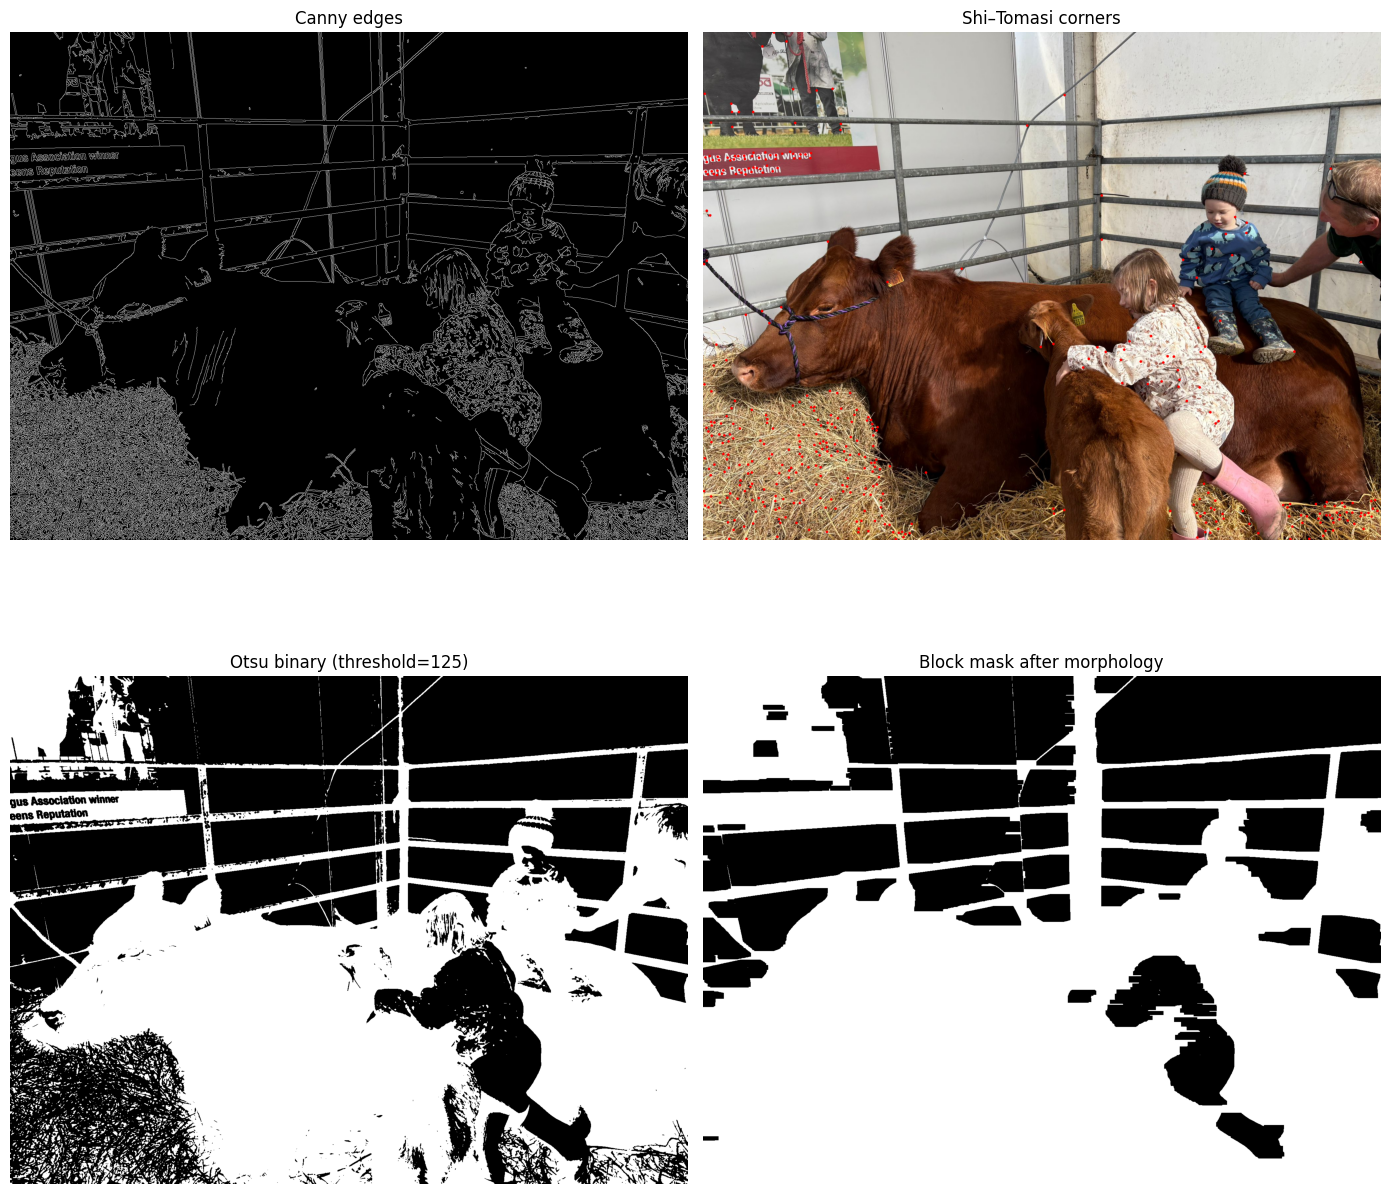

In [25]:
# ── Canny edge detection ───────────────────────────────────────
# Reference: OpenCV Canny tutorial
# https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
edges = cv2.Canny(img_blur, threshold1=60, threshold2=160)

# ── Shi–Tomasi corner keypoints ────────────────────────────────
# Reference: OpenCV goodFeaturesToTrack tutorial
# https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html
corners = cv2.goodFeaturesToTrack(
    img_blur, maxCorners=400, qualityLevel=0.01, minDistance=10
)
img_corners = img_rgb.copy()
if corners is not None:
    for pt in corners.astype(int).reshape(-1, 2):
        cv2.circle(img_corners, tuple(pt), 4, (255, 0, 0), -1)

# ── Otsu binarisation (WK6 Lab — cv2.threshold) ─────────────────
# THRESH_BINARY_INV : flip output so text -> 255, background -> 0
# THRESH_OTSU       : auto-pick threshold from the image histogram
otsu_value, binary = cv2.threshold(
    img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
print(f'Otsu auto-threshold value: {otsu_value:.0f}')

# ── Group characters into text blocks via morphological closing ─
# A horizontal kernel merges adjacent characters into line blobs;
# the slight vertical extent merges line blobs into paragraph blobs.
# Reference: OpenCV morphology tutorial
# https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
block_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (60, 12))
block_mask   = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, block_kernel)

# Single-mask layout pipeline: each connected component of `block_mask`
# is one document region. Sec. 2.3 classifies them by shape.
masks = {'block': block_mask}

# ── Stats ──────────────────────────────────────────────────────
print(f'Canny edge pixels : {int(edges.sum() // 255):,}')
print(f'Corner keypoints  : {0 if corners is None else len(corners)}')
print(f'Block mask pixels : {int(block_mask.sum() // 255):,} '
      f'({100 * int(block_mask.sum() // 255) / (H * W):.1f}% of page)')

# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].imshow(edges, cmap='gray');      axes[0, 0].set_title('Canny edges')
axes[0, 1].imshow(img_corners);             axes[0, 1].set_title('Shi–Tomasi corners')
axes[1, 0].imshow(binary, cmap='gray');     axes[1, 0].set_title(f'Otsu binary (threshold={otsu_value:.0f})')
axes[1, 1].imshow(block_mask, cmap='gray'); axes[1, 1].set_title('Block mask after morphology')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


---
## 2.3  Region Labelling — connected components group pixel blobs into regions classified by size and shape.

Each detected blob is labelled based purely on how large it is relative to the
whole image, and whether it is elongated. This makes the labels meaningful for
any image type -- photograph, chart, diagram, or document -- without assuming
the content is a page of text.

| Label | What it means |
|-------|---------------|
| `dominant` | Covers > 15% of the image — a main visual element |
| `major` | Covers 5–15% — a significant secondary region |
| `minor` | Covers 1–5% — a smaller but visible feature |
| `detail` | Covers < 1% — a small isolated fragment |
| `band` | Extreme aspect ratio (very wide or very tall strip) |


In [26]:
# Region colour palette
REGION_COLOURS = {
    "dominant" : ( 40, 160,  60),   # green  - covers > 15% of image
    "major"    : ( 30,  60, 200),   # blue   - covers 5-15%
    "minor"    : (220, 120,   0),   # orange - covers 1-5%
    "detail"   : (110, 110, 110),   # grey   - small isolated feature
    "band"     : (180,  60, 200),   # purple - elongated strip
}

MIN_AREA_RATIO = 0.001
min_area       = int(MIN_AREA_RATIO * H * W)

# ── Generic region classifier ─────────────────────────────────────────
# Labels are based on size relative to the image and aspect ratio only.
# No document-specific assumptions (no "header", "paragraph" etc.).
# Works for photographs, charts, diagrams, and document pages alike.
def classify_region(x, y, w, h, raw_mask=None):
    area       = w * h
    aspect     = w / max(h, 1)
    area_ratio = area / (H * W)

    # Elongated band -- very wide or very tall strip
    if aspect > 5 or aspect < 0.2:
        return "band"

    # Size-based labels
    if area_ratio > 0.15:
        return "dominant"
    elif area_ratio > 0.05:
        return "major"
    elif area_ratio > 0.01:
        return "minor"
    else:
        return "detail"

def extract_regions_from_mask(mask, default_label, raw_mask=None):
    n, _labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = []
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if area < min_area:
            continue
        label = classify_region(x, y, w, h, raw_mask=raw_mask)
        out.append((int(x), int(y), int(w), int(h), label))
    return out

# Gather all regions from the block mask
region_records = extract_regions_from_mask(block_mask, "block", raw_mask=binary)

# Sort largest first so small regions draw on top
region_records.sort(key=lambda r: r[2] * r[3], reverse=True)

print("Detected", len(region_records), "regions >=" , round(MIN_AREA_RATIO * 100, 1), "% of image area")
from collections import Counter
type_counts = Counter(r[4] for r in region_records)
for t in REGION_COLOURS:
    print(" ", t.ljust(10), ":", type_counts.get(t, 0))


Detected 1 regions >= 0.1 % of image area
  dominant   : 1
  major      : 0
  minor      : 0
  detail     : 0
  band       : 0


---
## 2.4  Bounding Boxes — colour-coded rectangles drawn over each region.
Green = dominant, blue = major, orange = minor, grey = detail, purple = band.


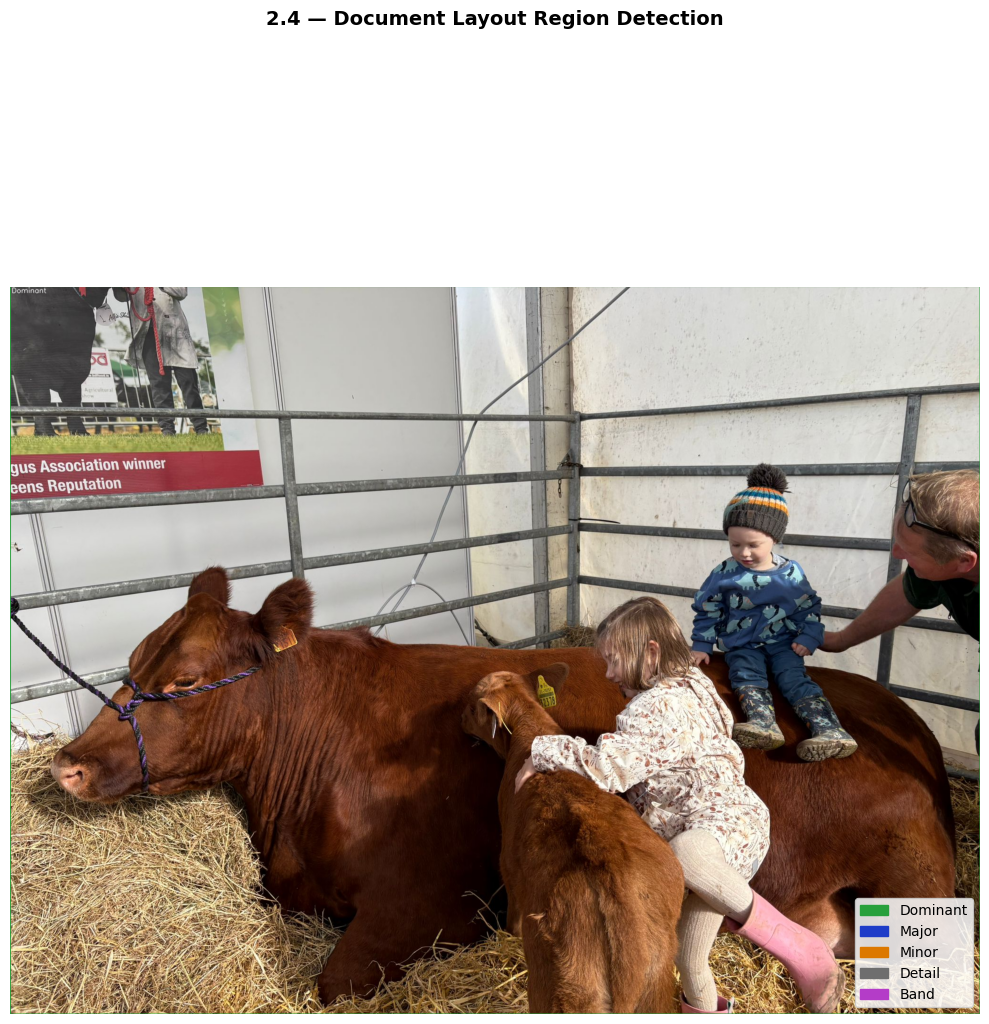

In [27]:
# ── Draw bounding boxes and text labels ────────────────────
# Uses REGION_COLOURS defined in Sec. 2.3.
# cv2.rectangle / cv2.putText pattern: WK6 Lab Code.
annotated = img_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX

for (x, y, w, h, rtype) in region_records:

    colour = REGION_COLOURS.get(rtype, (200, 200, 200))   # fallback grey
    label  = rtype.replace('_', ' ').title()

    # Bounding rectangle
    cv2.rectangle(annotated, (x, y), (x + w, y + h), colour, 2)

    # Filled label background then white text
    (tw, th), _ = cv2.getTextSize(label, font, 0.50, 1)
    cv2.rectangle(annotated, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
    cv2.putText(annotated, label, (x + 3, max(y - 4, th + 2)),
                font, 0.50, (255, 255, 255), 1, cv2.LINE_AA)

# ── Show the annotated document ───────────────────────
fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(annotated)
ax.axis('off')
plt.suptitle('2.4 — Document Layout Region Detection',
             fontsize=14, fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(color=np.array(c) / 255, label=t.replace('_', ' ').title())
                  for t, c in REGION_COLOURS.items()]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.85)
plt.tight_layout(); plt.show()


---
## 2.5  Lab7a Techniques -- blurring, thresholding, morphological operations, gradients, and histograms applied to the extracted figure.

All Lab7a techniques below operate on the same image loaded in Section 2.1
(`doc_largest_image.png` if found, otherwise the full rendered page).

| Technique | OpenCV call | What it shows |
|-----------|-------------|---------------|
| Blurring | `filter2D`, `GaussianBlur`, `medianBlur` | Noise smoothing at different radii |
| Thresholding | `threshold`, `adaptiveThreshold` | Fixed vs local-adaptive binarisation |


### 2.5.1  Blurring — 2D convolution, Gaussian, and median filters. Smooths noise before further analysis.

Three blurring filters are applied to the page. Each smooths different
kinds of noise:

- **2D convolution** with a uniform 3×3 kernel — averages neighbouring pixels.
- **Gaussian blur** — weighted average favouring the centre pixel; better
  preserves edges than uniform averaging.
- **Median blur** — replaces each pixel with the median of its neighbourhood;
  excellent at removing salt-and-pepper noise from scanned pages.

*Reference: Lab7a Cells 33–43; OpenCV smoothing tutorial —
https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html*


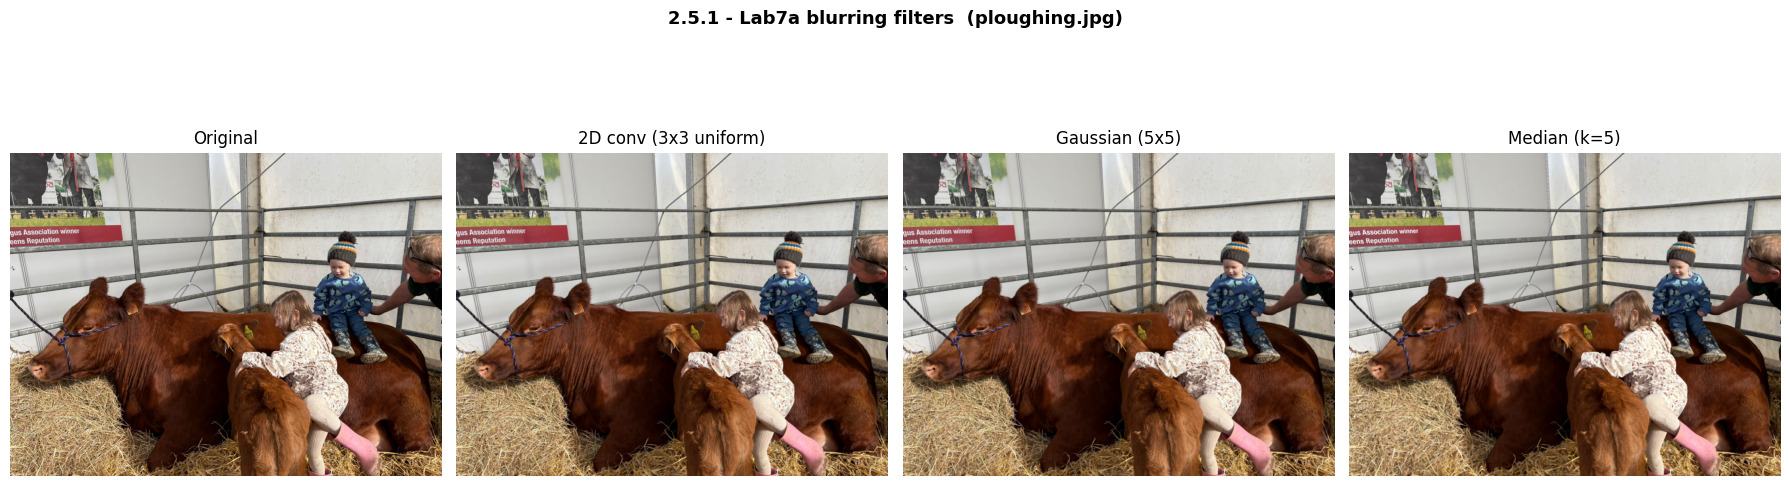

In [28]:
# Lab7a 2.5.1 - three blurring filters
# img_rgb was loaded in Section 2.1 (extracted figure or rendered page fallback).
# Lab7a pattern: cv2.filter2D, cv2.GaussianBlur, cv2.medianBlur.

# 1. 2D convolution - uniform 3x3 averaging kernel (Lab7a Cell 35)
kernel_2d   = np.ones((3, 3), dtype=np.float32) / 9.0
blur_2d     = cv2.filter2D(img_rgb, -1, kernel_2d)

# 2. Gaussian blur (Lab7a Cell 39)
blur_gauss  = cv2.GaussianBlur(img_rgb, (5, 5), 0)

# 3. Median blur - robust to salt-and-pepper noise (Lab7a Cell 43)
blur_median = cv2.medianBlur(img_rgb, 5)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(img_rgb);     axes[0].set_title("Original")
axes[1].imshow(blur_2d);     axes[1].set_title("2D conv (3x3 uniform)")
axes[2].imshow(blur_gauss);  axes[2].set_title("Gaussian (5x5)")
axes[3].imshow(blur_median); axes[3].set_title("Median (k=5)")
for ax in axes: ax.axis("off")
plt.suptitle("2.5.1 - Lab7a blurring filters  (" + IMAGE_FILE + ")", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


### 2.5.2  Thresholding — fixed binary cutoff versus adaptive local thresholding. Handles uneven lighting across the image.

Phase 2 already uses **Otsu** binarisation (Sec. 2.2). Lab7a adds two
more useful techniques for documents:

- **Plain binary threshold** at a fixed cutoff (here 127) — useful as a
  baseline for comparison with Otsu's auto-pick.
- **Adaptive thresholding** (mean and Gaussian variants) — picks a
  *local* threshold per pixel based on its neighbourhood. This handles
  uneven lighting on scanned pages much better than a single global
  threshold and is a standard pre-processing step before OCR.

*Reference: Lab7a Cells 47–55; OpenCV thresholding tutorial —
https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html*


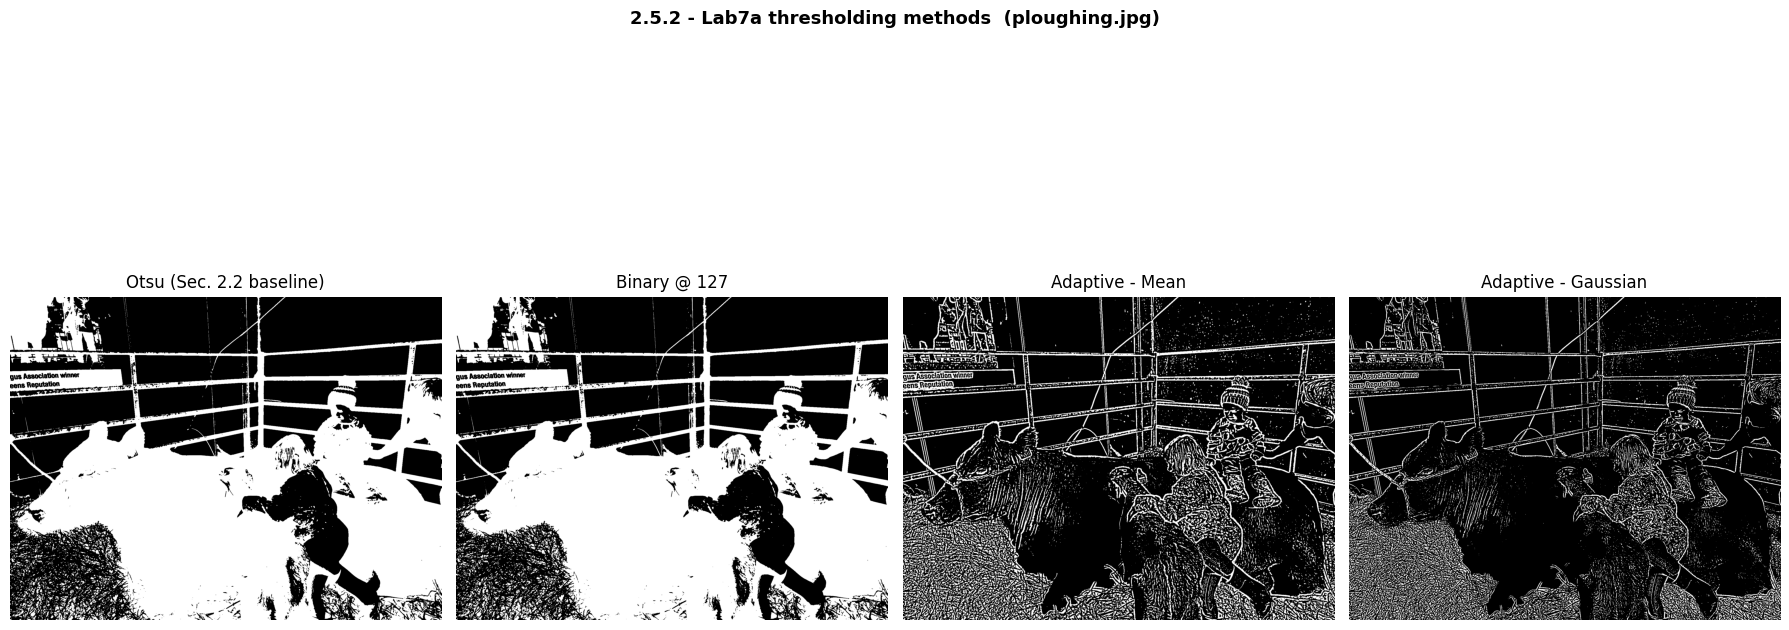

Adaptive thresholding gives a per-pixel cutoff -> handles uneven lighting.


In [29]:
# Lab7a 2.5.2 - binary + adaptive thresholding
# img_blur and binary are from Sections 2.1 / 2.2 (extracted figure or fallback).

# Plain binary threshold at fixed cutoff 127 (Lab7a Cell 48)
_, thresh_binary = cv2.threshold(img_blur, 127, 255, cv2.THRESH_BINARY_INV)

# Adaptive - mean of local neighbourhood (Lab7a Cell 54)
thresh_adapt_mean = cv2.adaptiveThreshold(
    img_blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV, 15, 8,
)

# Adaptive - Gaussian-weighted local neighbourhood (Lab7a Cell 55)
thresh_adapt_gauss = cv2.adaptiveThreshold(
    img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 15, 8,
)

fig, axes = plt.subplots(1, 4, figsize=(18, 9))
axes[0].imshow(binary,             cmap="gray"); axes[0].set_title("Otsu (Sec. 2.2 baseline)")
axes[1].imshow(thresh_binary,      cmap="gray"); axes[1].set_title("Binary @ 127")
axes[2].imshow(thresh_adapt_mean,  cmap="gray"); axes[2].set_title("Adaptive - Mean")
axes[3].imshow(thresh_adapt_gauss, cmap="gray"); axes[3].set_title("Adaptive - Gaussian")
for ax in axes: ax.axis("off")
plt.suptitle("2.5.2 - Lab7a thresholding methods  (" + IMAGE_FILE + ")", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("Adaptive thresholding gives a per-pixel cutoff -> handles uneven lighting.")


---
## 2.6  Crop Gallery — the three largest regions of each type cropped and displayed. Visual confirmation of classification accuracy.

The three largest detected regions of each type are cropped and displayed for visual inspection.
Coloured spine borders match the bounding-box colour scheme.

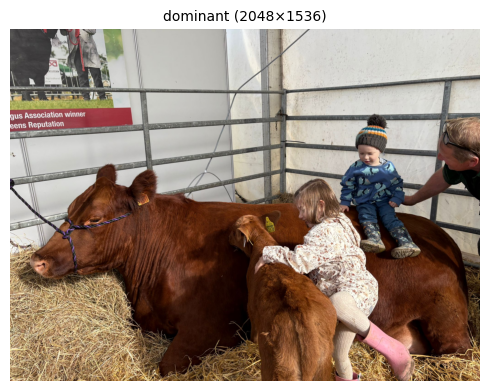

[major] No regions detected.
[minor] No regions detected.
[detail] No regions detected.
[band] No regions detected.


In [30]:
MAX_EXAMPLES = 3

for rtype, colour in REGION_COLOURS.items():
    examples = [(x, y, w, h) for (x, y, w, h, rt) in region_records if rt == rtype]
    if not examples:
        print(f'[{rtype}] No regions detected.')
        continue

    # Sort largest-first, take up to MAX_EXAMPLES
    examples.sort(key=lambda r: r[2] * r[3], reverse=True)
    show = examples[:MAX_EXAMPLES]
    colour_norm = tuple(c / 255 for c in colour)

    fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 4))
    if len(show) == 1:
        axes = [axes]
    for ax, (x, y, w, h) in zip(axes, show):
        crop = img_rgb[y:y + h, x:x + w]
        ax.imshow(crop)
        ax.set_title(f'{rtype} ({w}×{h})', fontsize=10)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(colour_norm)
            spine.set_linewidth(3)
    plt.tight_layout(); plt.show()

---
## 2.7  Region Summary Table — all detected regions compiled into a DataFrame with geometry, type, area, and aspect ratio.

All detected regions are compiled into a DataFrame with geometry (position, size, aspect) **and**
colour descriptors (mean H / S / V over the bounding box). Styled cells use a heatmap to highlight
the largest / most saturated regions.

In [31]:
rows = []
for (x, y, w, h, rtype) in region_records:
    area   = w * h
    aspect = round(w / (h + 1e-6), 2)

    # Fill ratio = fraction of bbox inside this region's own colour mask
    ref_mask = masks.get(rtype, uncovered)
    fg       = int((ref_mask[y:y + h, x:x + w] > 0).sum())
    fill     = round(fg / (area + 1e-6), 3)

    # Mean HSV inside the bounding box — colour fingerprint of the region
    crop_hsv = img_hsv[y:y + h, x:x + w]
    mean_h   = round(float(crop_hsv[:, :, 0].mean()), 1)
    mean_s   = round(float(crop_hsv[:, :, 1].mean()), 1)
    mean_v   = round(float(crop_hsv[:, :, 2].mean()), 1)

    rows.append({
        'Region Type'  : rtype,
        'X'            : x,
        'Y'            : y,
        'Width'        : w,
        'Height'       : h,
        'Area (px^2)'  : area,
        'Aspect (w/h)' : aspect,
        'Fill Ratio'   : fill,
        'Mean H'       : mean_h,
        'Mean S'       : mean_s,
        'Mean V'       : mean_v,
    })

df_regions = (
    pd.DataFrame(rows)
      .sort_values(['Region Type', 'Area (px^2)'], ascending=[True, False])
      .reset_index(drop=True)
)

print(f'Total regions in summary table: {len(df_regions)}')
(df_regions.style
    .background_gradient(subset=['Area (px^2)'],  cmap='YlOrBr')
    .background_gradient(subset=['Fill Ratio'],   cmap='Greens')
    .background_gradient(subset=['Mean S'],       cmap='PuRd')
    .set_caption('Detected Scene Regions — Sorted by Type & Area')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'),
                                  ('font-weight', 'bold')]}]))

NameError: name 'uncovered' is not defined

---
# 2.8  Robustness Check — runs the pipeline on non-document photos to show where it succeeds and where it degrades gracefully.

The brief frames the system around scanned documents, but a robust pipeline
should also degrade gracefully on other input. Two stress tests:

1. **`ploughing.jpg`** — a photograph from an agricultural show.
   The same Otsu + morphology + connected-components pipeline from Sections 2.1–2.4
   is applied unchanged, even though the image has no document-style structure.
2. **`seaside.jpg`** — a beach photograph with no text. Document binarisation
   has nothing meaningful to bite into, so this run uses the alternative
   **HSV colour segmentation** strategy (`cv2.inRange` per scene class with a
   priority chain).

These are explicitly framed as supplementary; the headline demo for the
assignment is the document analysis above.


## 2.8.1  Stress Test 1 (ploughing.jpg) — agricultural photo with no document structure. Pipeline finds edges but no meaningful text blocks.

Re-runs the document pipeline (binarisation -> morphology -> connected components
-> bounding boxes) on a photograph of an agricultural show. Unlike a scanned
page the image has no clean text/background histogram, so the document
pipeline degrades gracefully rather than producing meaningful regions —
exactly the kind of failure mode a robustness check is meant to expose.


In [ ]:
# Apply the document pipeline to an agricultural-show photo for comparison
ST1_FILE = 'ploughing.jpg'
st1_bgr  = cv2.imread(ST1_FILE)
if st1_bgr is None:
    raise FileNotFoundError(f"Could not load '{ST1_FILE}'")

st1_rgb  = cv2.cvtColor(st1_bgr, cv2.COLOR_BGR2RGB)
st1_gray = cv2.cvtColor(st1_bgr, cv2.COLOR_BGR2GRAY)
st1_blur = cv2.GaussianBlur(st1_gray, (5, 5), 0)
st1_H, st1_W = st1_gray.shape

# WK6-lab Otsu binarisation
_, st1_bin = cv2.threshold(st1_blur, 0, 255,
                           cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Morphological closing to merge characters into blocks
k = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 10))
st1_blocks = cv2.morphologyEx(st1_bin, cv2.MORPH_CLOSE, k)

# Connected components
n, _, stats, _ = cv2.connectedComponentsWithStats(st1_blocks, connectivity=8)
st1_min_area = int(0.002 * st1_H * st1_W)

annotated = st1_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX
kept = 0
for i in range(1, n):
    x, y, w, h, area = stats[i]
    if area < st1_min_area:
        continue
    kept += 1
    aspect = w / max(h, 1)
    if   w > 0.5 * st1_W and h < 100:                       label, colour = 'header',    (30, 60, 200)
    elif 0.6 < aspect < 1.6 and area > 0.04 * st1_H * st1_W: label, colour = 'figure',    (40, 160, 60)
    elif aspect > 4 and h < 60:                              label, colour = 'text_line', (110, 110, 110)
    else:                                                    label, colour = 'paragraph', (220, 120, 0)

    cv2.rectangle(annotated, (x, y), (x + w, y + h), colour, 2)
    (tw, th), _ = cv2.getTextSize(label, font, 0.5, 1)
    cv2.rectangle(annotated, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
    cv2.putText(annotated, label, (x + 3, max(y - 4, th + 2)),
                font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

print(f'Stress test 1 — kept {kept} regions')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(st1_rgb);   axes[0].set_title('Original — ploughing.jpg')
axes[1].imshow(annotated); axes[1].set_title('Document pipeline applied')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


## 2.8.2  Stress Test 2 (seaside.jpg) — uniform-colour landscape showing the limits of document binarisation on natural scenes.

Document binarisation finds nothing useful in a uniform-colour landscape, so
the seaside image is segmented with **HSV colour masking** (`cv2.inRange`)
plus a priority chain. This was the segmentation approach used in earlier
drafts of the notebook and is preserved here as a supplementary demonstration
of an alternative strategy.

*References:* `cv2.inRange` — https://docs.opencv.org/4.x/d2/de8/group__core__array.html ;
HSV colour space — OpenCV "Changing Colorspaces" tutorial:
https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html


In [ ]:
# HSV colour-based segmentation on a beach scene
ST2_FILE = 'seaside.jpg'
st2_bgr  = cv2.imread(ST2_FILE)
if st2_bgr is None:
    raise FileNotFoundError(f"Could not load '{ST2_FILE}'")

st2_rgb  = cv2.cvtColor(st2_bgr, cv2.COLOR_BGR2RGB)
st2_hsv  = cv2.cvtColor(st2_bgr, cv2.COLOR_BGR2HSV)
st2_H, st2_W = st2_rgb.shape[:2]

# HSV ranges per scene class (OpenCV hue range = 0–179)
COLOUR_RANGES = [
    ('sky',      [((90,  80, 120), (130, 255, 255))]),
    ('sea',      [((80,  60,  80), (110, 255, 220))]),
    ('mountain', [((40,  50,  50), (75,  255, 180))]),
    ('sand',     [((15,  40, 150), (40,  180, 255))]),
]

st2_masks = {}
claimed   = np.zeros(st2_hsv.shape[:2], dtype=np.uint8)

for name, ranges in COLOUR_RANGES:
    m = np.zeros(st2_hsv.shape[:2], dtype=np.uint8)
    for lo, hi in ranges:
        m |= cv2.inRange(st2_hsv, np.array(lo, dtype=np.uint8),
                                  np.array(hi, dtype=np.uint8))
    # Priority chain — each pixel claimed by at most one class
    m = cv2.bitwise_and(m, cv2.bitwise_not(claimed))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((5, 5), np.uint8))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    st2_masks[name] = m
    claimed       |= m

ST2_COLOURS  = {'sky': (255, 140, 0), 'sea': (255, 215, 0),
                'mountain': (255, 0, 255), 'sand': (0, 100, 200)}
ST2_MIN_AREA = int(0.005 * st2_H * st2_W)

annotated = st2_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX
kept = 0
for name, mask in st2_masks.items():
    n, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if area < ST2_MIN_AREA:
            continue
        kept  += 1
        colour = ST2_COLOURS[name]
        cv2.rectangle(annotated, (x, y), (x + w, y + h), colour, 2)
        (tw, th), _ = cv2.getTextSize(name, font, 0.5, 1)
        cv2.rectangle(annotated, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
        cv2.putText(annotated, name, (x + 3, max(y - 4, th + 2)),
                    font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

print(f'Stress test 2 — kept {kept} HSV-classified regions')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(st2_rgb);   axes[0].set_title('Original — seaside.jpg')
axes[1].imshow(annotated); axes[1].set_title('HSV scene segmentation')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


---
# Phase 3 -- Multi-Modal Integration
### OCR Word Boxes -> Spatial Join with Image Regions -> Unified JSON -> Summary Report
---

This phase
*Note*: from this notebook on Phase 2 operates on `doc_largest_image.png`
(the figure extracted in Section 2.0a from the page set by `PAGE_NUM` in Section 0),
so the Phase 3 OCR and spatial join below run on that same extracted figure --
the multi-modal output therefore describes one figure pulled from the imported
document rather than the title page used in Phase 1.

merges the outputs of Phase 1 (OCR + NLP on `ocr_text`) and
Phase 2 (`region_records` from connected components) into one structured
view of the page.

The four steps are:

1. **3.1** Re-run Tesseract via `pytesseract.image_to_data` to obtain
   word-level bounding boxes (Phase 1 only used `image_to_string`).
2. **3.2** Spatially join each OCR word box to the Phase 2 region it sits in,
   yielding one record per word with text + region geometry + region class.
3. **3.3** Build a single nested JSON object (one entry per region) that
   contains the region geometry, density class, OCR words inside it, and a
   summary line.
4. **3.4** Print a short human-readable summary of the unified output.


## 3.1  Word Bounding Boxes — pytesseract re-run in data mode to capture the pixel position of every OCR word.

`pytesseract.image_to_string` (used in Phase 1) discards geometry. To map
text onto the regions detected in Phase 2 we need each word's `(left, top,
width, height)`, which Tesseract exposes via the TSV output mode.

*Reference: pytesseract `image_to_data` — https://github.com/madmaze/pytesseract*  
*Reference: Tesseract TSV output format — https://tesseract-ocr.github.io/tessdoc/Command-Line-Usage.html*


In [ ]:
# -- OCR with word-level bounding boxes ------------------------------------
# Phase 1 used pytesseract.image_to_string (raw text only).
# image_to_data runs the SAME OCR pass but returns per-word geometry
# (left, top, width, height, conf), which is what Phase 3 needs.
#
# Reference: pytesseract.image_to_data
#   https://github.com/madmaze/pytesseract
# Reference: Tesseract TSV output columns
#   https://tesseract-ocr.github.io/tessdoc/Command-Line-Usage.html
#
# img_bgr was loaded in Sec. 2.1 via cv2.imread (WK6 lab pattern).

custom_config = r'--oem 1 --psm 6'   # same engine + page-segmentation as Phase 1

ocr_data = pytesseract.image_to_data(
    img_bgr,
    config=custom_config,
    output_type=pytesseract.Output.DICT,
)

# Keep only rows where Tesseract emitted an actual word with non-zero confidence
words = []
for i in range(len(ocr_data['text'])):
    txt  = ocr_data['text'][i].strip()
    raw_conf = ocr_data['conf'][i]
    try:
        conf = float(raw_conf)
    except (TypeError, ValueError):
        conf = -1.0
    if txt and conf > 0:
        words.append({
            'text' : txt,
            'conf' : round(conf, 1),
            'x'    : int(ocr_data['left'][i]),
            'y'    : int(ocr_data['top'][i]),
            'w'    : int(ocr_data['width'][i]),
            'h'    : int(ocr_data['height'][i]),
        })

print(f'Extracted {len(words)} word-level bounding boxes from OCR.')
print('First 5 words:')
for w in words[:5]:
    print(f"  '{w['text']:<20}' conf={w['conf']:>5}  bbox=({w['x']},{w['y']},{w['w']},{w['h']})")


## 3.2  Spatial Join — each OCR word assigned to the Phase 2 region whose bounding box contains it.

A word "belongs" to a region if the centre of its OCR bounding box lies
inside the region's rectangle. Phase 2's regions come from
`cv2.connectedComponentsWithStats`, so they are already axis-aligned —
a few lines of arithmetic are enough; no extra OpenCV calls needed.

*Reference: OpenCV equivalent for arbitrary contours is `cv2.pointPolygonTest` —  
https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html*


In [ ]:
# -- Spatial join: assign each OCR word to a Phase-2 image region ----------
# Pure-Python point-in-rectangle test (the regions are axis-aligned).
# OpenCV equivalent for general contours: cv2.pointPolygonTest.

def _centre(word):
    return (word['x'] + word['w'] // 2, word['y'] + word['h'] // 2)

def _contains(region, point):
    rx, ry, rw, rh, _ = region
    px, py = point
    return rx <= px <= rx + rw and ry <= py <= ry + rh

# Build region_id -> [words] mapping. Iterate smallest-first so a word that
# falls inside both a tight text_line and the paragraph that wraps it is
# attributed to the tighter region.
regions_small_first = sorted(
    list(enumerate(region_records)),
    key=lambda ir: ir[1][2] * ir[1][3],
)

region_to_words = {i: [] for i, _ in regions_small_first}
unassigned = []

for w in words:
    centre = _centre(w)
    matched_id = None
    for i, region in regions_small_first:
        if _contains(region, centre):
            matched_id = i
            break
    if matched_id is None:
        unassigned.append(w)
    else:
        region_to_words[matched_id].append(w)

# Coverage stats
total = len(words)
assigned = total - len(unassigned)
print(f'Words assigned to a region : {assigned}/{total} ({assigned/total:.0%})')
print(f'Words outside any region   : {len(unassigned)}')

# Show top-5 most word-dense regions
dense = sorted(
    ((i, len(ws)) for i, ws in region_to_words.items()),
    key=lambda t: t[1], reverse=True
)[:5]
print()
print('Top-5 word-dense regions:')
for rid, n in dense:
    if n == 0:
        break
    x, y, w_, h_, rtype = region_records[rid]
    print(f'  region #{rid:>3}  type={rtype:<10}  bbox=({x},{y},{w_},{h_})  words={n}')


## 3.3  Unified Overlay — region boxes and OCR word boxes drawn together on the same image. Confirms the spatial join worked.

Region rectangles (thick, colour-coded by type) and OCR word rectangles
(thin yellow) are drawn on the same canvas. Text labels for each region
follow the same `cv2.putText` styling used in Sec. 2.4 and in the WK6
lab's annotated-image example.

*WK6 Lab Code reused: `cv2.imread`, `cv2.cvtColor`, `cv2.rectangle`, `cv2.putText`, `cv2.imwrite`.*


In [ ]:
# -- Unified annotated overlay: region boxes + OCR word boxes --------------
# Uses WK6 lab patterns end-to-end (cv2.rectangle, cv2.putText, cv2.imwrite).

unified = img_rgb.copy()
font = cv2.FONT_HERSHEY_SIMPLEX

# 1. Region rectangles (thick) -- same palette as Sec. 2.4
for (x, y, w_, h_, rtype) in region_records:
    colour = REGION_COLOURS.get(rtype, (200, 200, 200))
    cv2.rectangle(unified, (x, y), (x + w_, y + h_), colour, 3)

# 2. OCR word rectangles (thin yellow) layered on top
WORD_COLOUR = (255, 215, 0)
for w in words:
    cv2.rectangle(
        unified,
        (w['x'], w['y']),
        (w['x'] + w['w'], w['y'] + w['h']),
        WORD_COLOUR, 1,
    )

# 3. Region-type labels -- cv2.putText pattern from WK6
for (x, y, w_, h_, rtype) in region_records:
    colour = REGION_COLOURS.get(rtype, (200, 200, 200))
    label  = rtype.replace('_', ' ').title()
    (tw, th), _ = cv2.getTextSize(label, font, 0.55, 1)
    cv2.rectangle(unified, (x, max(y - th - 6, 0)), (x + tw + 6, y), colour, -1)
    cv2.putText(unified, label, (x + 3, max(y - 4, th + 2)),
                font, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(14, 18))
plt.imshow(unified)
plt.title('Phase 3 - Unified View: Image Regions (thick) + OCR Word Boxes (thin yellow)')
plt.axis('off')
plt.tight_layout()
plt.show()

# -- Save the unified figure to disk (WK6 lab: cv2.imwrite) ----------------
OUT_PNG = 'ca2_doc_phase3_unified.png'
cv2.imwrite(OUT_PNG, cv2.cvtColor(unified, cv2.COLOR_RGB2BGR))
print(f"Saved unified annotated image to '{OUT_PNG}'")


## 3.4  JSON Output — each region exported as a structured record combining geometry, word text, entities, and sentiment.

Each Phase-2 region is emitted as a JSON record carrying:

| Field | Source |
|-------|--------|
| `region_id`, `region_type`, `bbox` | Phase 2 — `cv2.connectedComponentsWithStats` (Sec. 2.3) |
| `ocr_text`, `word_count`           | Phase 3.1 + 3.2 spatial join                          |
| `entities`                         | spaCy NER (Phase 1, Sec. 4)                           |
| `sentiment`                        | VADER (Phase 1, Sec. 10)                              |

The whole document is then written to disk as a single JSON file —
this is the "unified pipeline output" asked for by the Week 4 brief.

*Reference: Python `json` standard library — https://docs.python.org/3/library/json.html*


In [ ]:
# -- Build the unified multi-modal record per region -----------------------
# Combines Phase-2 geometry with Phase-1 NLP outputs (NER, VADER).
#
# Reference: Python json module
#   https://docs.python.org/3/library/json.html

import json

multimodal = []
for i, (x, y, w_, h_, rtype) in enumerate(region_records):
    region_words = region_to_words.get(i, [])
    region_text  = ' '.join(w['text'] for w in region_words)

    # spaCy NER on this region's text only (re-uses `nlp` from Phase 1 cell 4)
    ents = []
    if region_text.strip():
        ents = [
            {'text': e.text, 'label': e.label_}
            for e in nlp(region_text).ents
        ]

    # VADER sentiment on this region's text (re-uses `sia` from Sec. 10)
    if region_text.strip():
        sent = sia.polarity_scores(region_text)
    else:
        sent = {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}

    multimodal.append({
        'region_id'   : i,
        'region_type' : rtype,
        'bbox'        : {'x': int(x), 'y': int(y), 'w': int(w_), 'h': int(h_)},
        'word_count'  : len(region_words),
        'ocr_text'    : region_text,
        'entities'    : ents,
        'sentiment'   : {k: round(v, 3) for k, v in sent.items()},
    })

# Persist the whole document to disk
OUT_JSON = 'ca2_doc_multimodal.json'
with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump({
        'source_image' : IMAGE_FILE,
        'page_size'    : {'height': int(H), 'width': int(W)},
        'n_regions'    : len(multimodal),
        'n_words'      : len(words),
        'regions'      : multimodal,
    }, f, indent=2, ensure_ascii=False)

print(f"Wrote '{OUT_JSON}' -- {len(multimodal)} regions, {len(words)} OCR words.")

# -- Preview the first text-bearing region ---------------------------------
preview = next((r for r in multimodal if r['word_count'] > 0), None)
if preview:
    print()
    print('=== Sample region record ===')
    print(json.dumps(preview, indent=2, ensure_ascii=False)[:1200])
else:
    print('No text-bearing region found to preview.')


## 3.5  Summary Report — per-region table of word counts, entity counts, and sentiment scores.

A compact table showing per-region geometry, word count, entity count,
sentiment polarity and a short text snippet, followed by headline insights
across the whole page.


In [ ]:
# -- Per-region summary table ----------------------------------------------
summary_rows = []
for r in multimodal:
    summary_rows.append({
        'Region'   : f"#{r['region_id']} {r['region_type']}",
        'BBox'     : f"({r['bbox']['x']},{r['bbox']['y']}) {r['bbox']['w']}x{r['bbox']['h']}",
        'Words'    : r['word_count'],
        'Entities' : len(r['entities']),
        'Compound' : r['sentiment']['compound'],
        'Snippet'  : (r['ocr_text'][:60] + '...') if len(r['ocr_text']) > 60 else r['ocr_text'],
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Phase 3 Region Summary ===')
print(summary_df.to_string(index=False))

# -- Headline insights ------------------------------------------------------
text_regions = [r for r in multimodal if r['word_count'] > 0]
all_entities = [e for r in multimodal for e in r['entities']]
ent_counts   = Counter(e['label'] for e in all_entities)

print()
print('=== Headline Insights ===')
print(f'  Regions detected         : {len(multimodal)}')
print(f'  Regions carrying text    : {len(text_regions)}')
print(f'  Words placed in a region : {sum(r["word_count"] for r in multimodal)}/{len(words)}')
print(f'  Total NE mentions        : {len(all_entities)}')
if ent_counts:
    print('  Top entity types         : ' +
          ', '.join(f'{lbl}={cnt}' for lbl, cnt in ent_counts.most_common(5)))
if text_regions:
    densest = max(text_regions, key=lambda r: r['word_count'])
    print(f'  Densest text region      : #{densest["region_id"]} '
          f'({densest["region_type"]}) -- {densest["word_count"]} words')
    overall_compound = sum(r['sentiment']['compound'] for r in text_regions) / len(text_regions)
    print(f'  Mean region sentiment    : compound = {overall_compound:+.3f}')


---
## 3.6  LLM Document Prediction — Ollama (llama3.2:3b)

Rather than relying on frequency counts alone, this section feeds the pipeline's
extracted features directly into a locally-running **Llama 3.2 (3B)** model via
**Ollama** to produce a natural-language prediction of:

1. **Topic** — what subject this document is about
2. **Document type** — academic paper, report, manual, article, etc.
3. **Likely source** — where this document probably comes from

The prompt is built from the curated pipeline outputs already in memory
(TF-IDF keywords, noun chunks, NER entities, and a short OCR text excerpt)
rather than raw OCR text, so the model receives clean, structured signal
rather than noisy scanner output.

**Requires:** Ollama running locally (`ollama serve`) with `llama3.2:3b` pulled.
If the `ollama` Python package is not installed, the cell falls back to the
Ollama HTTP API (`http://localhost:11434`).


In [ ]:
# -- Section 3.6  LLM Document Prediction via Ollama (llama3.2:3b) ----------
# Pattern adapted from CLI_2.ipynb (DBA project):
#   - streaming NDJSON via requests + iter_lines() (no ollama library needed)
#   - warm-up call to load the model into RAM before the main prompt
#   - temperature=0.1 for consistent, deterministic output
#   - 600 s timeout; ConnectionError caught separately for a clear message
#
# References:
#   Ollama REST API:  https://github.com/ollama/ollama/blob/main/docs/api.md
#   Meta Llama 3.2:   https://ollama.com/library/llama3.2

import json
import requests

OLLAMA_URL   = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "llama3.2:3b"

# -- (1) Warm up the model ---------------------------------------------------
def _warm_up(model=OLLAMA_MODEL, url=OLLAMA_URL):
    print(f"Warming up '{model}' (may take 30-60 s on first run)...",
          end="", flush=True)
    try:
        requests.post(url, json={
            "model":  model,
            "prompt": "Reply with: ok",
            "stream": False,
            "options": {"num_predict": 4},
        }, timeout=600)
        print(" ready.")
    except Exception as e:
        print(f" warm-up failed ({e}) -- first call may be slow.")

_warm_up()

# -- (2) Build context from pipeline outputs already in memory ---------------
_tfidf_terms  = ', '.join(weights.head(12).index.tolist())

_doc_pred = nlp(ocr_text)

_noun_phrases = ', '.join(
    c.text.strip().lower()
    for c in _doc_pred.noun_chunks
    if 2 < len(c.text) < 50
)[:400]

_ent_by_type = {}
for e in _doc_pred.ents:
    _ent_by_type.setdefault(e.label_, []).append(e.text.strip())
_ner_summary = '; '.join(
    f"{lbl}: {', '.join(list(dict.fromkeys(items))[:3])}"
    for lbl, items in sorted(_ent_by_type.items())
) or 'none detected'

_excerpt = ' '.join(ocr_text[:600].split())[:500]

# -- (3) Print the context being sent to the model ---------------------------
print("=== Context sent to model ===")
print(f"  TF-IDF keywords : {_tfidf_terms}")
print(f"  Noun phrases    : {_noun_phrases}")
print(f"  Named entities  : {_ner_summary}")
print(f"  Text excerpt    : {_excerpt}")
print()

# -- (4) Compose prompt ------------------------------------------------------
_prompt = f"""You are a document analysis assistant. The following features were
automatically extracted from a scanned document page using an NLP pipeline.

Top TF-IDF keywords : {_tfidf_terms}
Key noun phrases    : {_noun_phrases}
Named entities      : {_ner_summary}
Text excerpt        : {_excerpt}

Based solely on these features, answer the following three questions.
Be concise -- 1 to 2 sentences per answer.

1. What subject or topic is this document about?
2. What type of document is this (e.g. academic paper, news article, technical manual, government report)?
3. Where does this document likely come from (e.g. academic journal, textbook, website, internal report)?"""

# -- (5) Stream response (pattern from CLI_2.ipynb) --------------------------
def _ask_ollama_stream(prompt, model=OLLAMA_MODEL, url=OLLAMA_URL, timeout=600):
    payload = {
        "model":   model,
        "prompt":  prompt,
        "stream":  True,
        "options": {"temperature": 0.1},
    }
    try:
        with requests.post(url, json=payload, timeout=timeout, stream=True) as r:
            r.raise_for_status()
            pieces = []
            for raw_line in r.iter_lines(decode_unicode=True):
                if not raw_line:
                    continue
                try:
                    obj = json.loads(raw_line)
                except json.JSONDecodeError:
                    continue
                tok = obj.get("response", "")
                if tok:
                    print(tok, end="", flush=True)
                    pieces.append(tok)
                if obj.get("done"):
                    break
            print()
            return "".join(pieces).strip()
    except requests.exceptions.ConnectionError:
        return (f"[ERROR] Could not reach Ollama at {url}. "
                f"Run `ollama serve` and `ollama pull {model}`.")
    except Exception as e:
        return f"[ERROR] LLM call failed: {e}"

print("=== Section 3.6  LLM Document Prediction ===")
print("-" * 72)
print("Answer:  ", end="", flush=True)
_llm_answer = _ask_ollama_stream(_prompt)
print("-" * 72)


---
# References

External libraries and techniques used in this notebook beyond the WK2 and WK6
lab code:

**Lab code reused or adapted directly**
- WK6 Lab Code (`WK6LabCode.docx`) — `cv2.imread`, `cv2.cvtColor`,
  `cv2.GaussianBlur`, `cv2.threshold` (BINARY / BINARY_INV / OTSU),
  `cv2.rectangle`, `cv2.putText`, `cv2.imwrite`.
- Lab7a Image Processing (`Lab7a_ImageProcessing.ipynb`) — Section 2.5
  techniques applied to `doc_largest_image.png` (the figure extracted in Section 2.0a): `cv2.filter2D`, `cv2.medianBlur`,
  `cv2.adaptiveThreshold` (mean / Gaussian), `cv2.erode`,
  `cv2.morphologyEx` (OPEN / CLOSE / GRADIENT), `cv2.Sobel`,
  `cv2.Laplacian`, `cv2.calcHist`.
- WK2 Lab Code (`Wk2LaCode.docx`, `Wk2Lb.docx`) — spaCy / NLTK tokenisation,
  stopword handling, NER, `noun_chunks`, dependency parsing, displaCy rendering.

**Python NLP libraries**
- pytesseract (Tesseract OCR Python wrapper) — https://github.com/madmaze/pytesseract
- spaCy NLP library and `en_core_web_sm` model — https://spacy.io/models/en
- NLTK — https://www.nltk.org/
- VADER sentiment (Hutto & Gilbert, 2014) —
  https://www.nltk.org/api/nltk.sentiment.vader.html
- scikit-learn `CountVectorizer` / `TfidfVectorizer` —
  https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

**OpenCV image-processing techniques used beyond the WK6 lab**
- Canny edge detection — https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
- Shi–Tomasi corners (`goodFeaturesToTrack`) —
  https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html
- Morphological transformations (`getStructuringElement`, `morphologyEx`) —
  https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
- Connected components (`connectedComponentsWithStats`) —
  https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html
- Otsu thresholding —
  https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
- HSV colour-space segmentation (`inRange`) —
  https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html

**PDF rendering (Section 0)**
Used to render the source PDF to a 200 DPI PNG so the cv2.imread + WK6-lab
pipeline can ingest it. The notebook tries `pypdfium2` first and falls back
to PyMuPDF if it isn't installed.
- pypdfium2 (Google PDFium binding, preferred — no system deps) —
  https://pypdfium2.readthedocs.io/en/stable/
- PyMuPDF / `fitz` (Artifex MuPDF binding, fallback) —
  https://pymupdf.readthedocs.io/en/latest/

**Phase 3 — Multi-Modal Integration sources**
- pytesseract `image_to_data` (word-level OCR boxes) —
  https://github.com/madmaze/pytesseract
- Tesseract TSV output format (column meanings: level, left, top, width,
  height, conf, text) —
  https://tesseract-ocr.github.io/tessdoc/Command-Line-Usage.html
- OpenCV `pointPolygonTest` (point-in-contour test referenced as the
  general-contour equivalent of the axis-aligned check used in Sec. 3.2) —
  https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html
- Python `json` standard library (structured Phase-3 output in Sec. 3.4) —
  https://docs.python.org/3/library/json.html

**Region classification — density-based figure detection (Sec. 2.3)**
- Wong, K. Y., Casey, R. G., & Wahl, F. M. (1982). "Document analysis
  system." IBM Journal of Research and Development, 26(6), 647–656.
  https://doi.org/10.1147/rd.266.0647 — foundational paper for
  Run-Length Smoothing + foreground-density classification, the
  classical (non-deep-learning) approach to printed-page layout.
- Bloomberg, D. S. — Leptonica papers on multiresolution morphology
  for document image analysis (the same halftone/figure detection
  approach Tesseract uses internally) —
  https://www.leptonica.org/papers.html

**Document-layout-analysis recipe**
The "binarise -> morphological close (horizontal kernel) -> connected components
-> bounding boxes" pipeline used in Sections 2.2–2.4 is the standard recipe
from OpenCV's text-detection examples and most introductory document-analysis
tutorials.

**Section 3.6 -- Page Topic Prediction**

- spaCy linguistic features -- noun chunks:
  https://spacy.io/usage/linguistic-features#noun-chunks
- spaCy linguistic features -- named entities:
  https://spacy.io/usage/linguistic-features#named-entities
- Luhn, H. P. (1958). *The Automatic Creation of Literature Abstracts.*
  IBM Journal of Research and Development, 2(2), 159-165.
  https://doi.org/10.1147/rd.22.0159
